# Bengali Document Image Retrieval — SSA-Embed (Kaggle)

Kaggle-adapted version of the SSA-Embed pipeline. Runs end-to-end on a Kaggle GPU notebook.

**What this notebook does**
1. **(A) SSA-Embed** — Script-Structure-Aware fine-tuning of SigLIP2 with:
   - **instance-level InfoNCE** on two augmented views of each page (the primary training signal),
   - **cosine distillation** to a frozen SigLIP2 teacher (anchors the student to the zero-shot embedding space),
   - **light SSA aux heads** (matra / conjunct / baseline pseudo-labels) as weak regularizers.
2. **(E) Degradation robustness** — Recall@K vs. severity across 6 document degradations.

**Kaggle setup**
- Attach the dataset **`bendir_goruped_sample`** (Add data → search this name).
- Turn on **GPU** (Settings → Accelerator → GPU T4 / P100).
- Turn on **Internet** (needed for the HuggingFace model download).

**Assumed dataset layout inside the Kaggle input folder**
```
/kaggle/input/bendir-goruped-sample/
  <category_1>/  train/  val/  test/
  <category_2>/  train/  val/  test/
  ...
```
Categories are auto-discovered — the notebook does not hard-code them.

**Persistence & resume**
All artifacts are written under `/kaggle/working/bendir_out/`:
- `state.json` — step-completion tracker (checked at every step),
- `ssa_epoch_v2_*.pt` — LATEST per-epoch training checkpoint only (pruned every epoch, deleted after the stage is `mark_done`, so /kaggle/working stays under 20 GB),
- `ssa_embed_v2.pt` — best-val SSA-Embed weights (also copied to `ssa_embed.pt` for downstream compat),
- `test_embeddings.npy`, `test_labels.npy`, `test_paths.json` — gallery,
- `faiss_test.index` — FAISS index for the test gallery,
- `degradation_results.csv` — appended per (degradation, severity),
- `robustness_curves.png`, `summary.json`.

If the session times out, **re-run all cells from the top**. Each expensive step reads its checkpoint and skips or resumes.


## 1. Environment setup

In [4]:
!pip install -q -U transformers faiss-cpu
!pip install -q "albumentations>=1.4,<2"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 101.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 84.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 11.0 MB/s eta 0:00:00


In [5]:
import os, json, random, math, glob, warnings, shutil, time
import sys
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import faiss

warnings.filterwarnings('ignore')

_prev_unraisable = sys.unraisablehook
def _silence_dl_finalizer(unraisable):
    exc = unraisable.exc_value
    if isinstance(exc, AssertionError) and 'child process' in str(exc):
        return
    _prev_unraisable(unraisable)
sys.unraisablehook = _silence_dl_finalizer

SEED = 44
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    ws = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(ws); random.seed(ws)

def make_generator(seed: int = SEED) -> torch.Generator:
    g = torch.Generator(); g.manual_seed(seed); return g

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '| faiss:', faiss.__version__, '| SEED:', SEED)


Device: cuda | faiss: 1.15.0 | SEED: 44


## 2. Dataset paths, auto-discovery, and output layout

In [6]:
DATA_ROOT_OVERRIDE = '/kaggle/input/datasets/kalyannandi0007/bendir-dataset-final-v3/_bendir-dataset-final-v3'

KAGGLE_INPUT = Path('/kaggle/input')

def locate_dataset(input_root: Path, name_hint: str = 'bendir') -> Path:
    if not input_root.exists():
        raise FileNotFoundError(f'{input_root} not found.')
    matches = [p for p in input_root.iterdir() if p.is_dir() and name_hint.lower() in p.name.lower()]
    if not matches:
        avail = [p.name for p in input_root.iterdir() if p.is_dir()]
        raise FileNotFoundError(
            f'No dataset containing "{name_hint}" under {input_root}. Available: {avail}.'
        )
    if len(matches) > 1:
        print(f'Multiple matches, picking first: {[m.name for m in matches]}')
    return matches[0]

if DATA_ROOT_OVERRIDE:
    DATA_ROOT = Path(DATA_ROOT_OVERRIDE)
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f'DATA_ROOT_OVERRIDE points to {DATA_ROOT} but it does not exist.')
else:
    DATA_ROOT = locate_dataset(KAGGLE_INPUT, name_hint='bendir')
print('DATA_ROOT =', DATA_ROOT)

SPLITS = ['train', 'val', 'test']
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp', '.webp')

def discover_categories(root: Path) -> List[str]:
    cats = []
    for p in sorted(root.iterdir()):
        if not p.is_dir():
            continue
        if any((p / s).exists() and (p / s).is_dir() for s in SPLITS):
            cats.append(p.name)
    return cats

CATEGORIES = discover_categories(DATA_ROOT)
if not CATEGORIES:
    raise RuntimeError(f'No categories with train/val/test found under {DATA_ROOT}')
print(f'Discovered {len(CATEGORIES)} categories: {CATEGORIES}')

IMG_SIZE = 384
BATCH_SIZE = 16
NUM_WORKERS = 2
EMBED_DIM = 512

OUT_DIR = Path('/kaggle/working/bendir_out')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('OUT_DIR =', OUT_DIR)

def list_split(split: str) -> List[Tuple[Path, str]]:
    items = []
    for cat in CATEGORIES:
        folder = DATA_ROOT / cat / split
        if not folder.exists():
            continue
        for p in folder.rglob('*'):
            if p.suffix.lower() in IMAGE_EXTS:
                items.append((p, cat))
    return items

counts = {s: len(list_split(s)) for s in SPLITS}
print('Per-split counts:', counts)
for cat in CATEGORIES:
    per = {s: sum(1 for p, c in list_split(s) if c == cat) for s in SPLITS}
    print(f'  {cat:20s} -> {per}')


DATA_ROOT = /kaggle/input/datasets/kalyannandi0007/bendir-dataset-final-v3/_bendir-dataset-final-v3
Discovered 7 categories: ['advertisements', 'book_covers', 'books', 'comics', 'magazines', 'news_papers', 'poems']
OUT_DIR = /kaggle/working/bendir_out
Per-split counts: {'train': 8035, 'val': 2009, 'test': 6047}
  advertisements       -> {'train': 478, 'val': 120, 'test': 325}
  book_covers          -> {'train': 311, 'val': 78, 'test': 165}
  books                -> {'train': 1978, 'val': 494, 'test': 1674}
  comics               -> {'train': 885, 'val': 221, 'test': 987}
  magazines            -> {'train': 1765, 'val': 441, 'test': 1088}
  news_papers          -> {'train': 1475, 'val': 369, 'test': 543}
  poems                -> {'train': 1143, 'val': 286, 'test': 1265}


## 3. Checkpoint / resume utilities

Every long-running step consults `state.json` and its own on-disk artifacts. If the session dies, re-running the notebook picks up where it left off.

In [7]:
STATE_FILE = OUT_DIR / 'state.json'

def load_state() -> dict:
    if STATE_FILE.exists():
        try:
            return json.loads(STATE_FILE.read_text())
        except Exception:
            return {}
    return {}

def save_state(s: dict) -> None:
    tmp = STATE_FILE.with_suffix('.json.tmp')
    tmp.write_text(json.dumps(s, indent=2, default=str))
    tmp.replace(STATE_FILE)

def mark_done(step: str, extra: Optional[dict] = None) -> None:
    s = load_state()
    s[step] = {'done': True, 'ts': datetime.utcnow().isoformat() + 'Z'}
    if extra:
        s[step].update(extra)
    save_state(s)

def is_done(step: str) -> bool:
    return bool(load_state().get(step, {}).get('done', False))

SNAPSHOT_SLUG        = 'bendir-ssa-embed-artifacts-seed44'
SNAPSHOT_TITLE       = 'Bendir SSA-Embed Artifacts Seed44'
SNAPSHOT_PUBLIC      = False
SNAPSHOT_MAX_FILE_GB = 10

def _snapshot_have_kaggle_creds() -> bool:
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        if not os.environ.get('KAGGLE_USERNAME'):
            os.environ['KAGGLE_USERNAME'] = us.get_secret('KAGGLE_USERNAME')
        if not os.environ.get('KAGGLE_KEY'):
            os.environ['KAGGLE_KEY'] = us.get_secret('KAGGLE_KEY')
    except Exception:
        pass
    return bool(os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'))

def _snapshot(tag: str = 'auto') -> bool:
    import subprocess
    if not _snapshot_have_kaggle_creds():
        print(f'[snapshot:{tag}] no kaggle credentials; skipping')
        return False
    username = os.environ['KAGGLE_USERNAME']
    STAGE = Path('/kaggle/working/_snapshot_stage')
    if STAGE.exists():
        shutil.rmtree(STAGE)
    STAGE.mkdir(parents=True)
    # Hardlink every file from OUT_DIR into STAGE so staging costs zero extra disk.
    max_bytes = SNAPSHOT_MAX_FILE_GB * (1024 ** 3)
    n_linked = 0
    total_bytes = 0
    skipped_too_big = []
    for src in OUT_DIR.rglob('*'):
        if not src.is_file():
            continue
        sz = src.stat().st_size
        if sz > max_bytes:
            skipped_too_big.append((str(src.relative_to(OUT_DIR)), sz))
            continue
        dst = STAGE / src.relative_to(OUT_DIR)
        dst.parent.mkdir(parents=True, exist_ok=True)
        try:
            os.link(src, dst)
        except OSError:
            shutil.copy2(src, dst)
        n_linked += 1
        total_bytes += sz
    (STAGE / 'dataset-metadata.json').write_text(json.dumps({
        'title': SNAPSHOT_TITLE,
        'id': f'{username}/{SNAPSHOT_SLUG}',
        'licenses': [{'name': 'CC0-1.0'}],
    }, indent=2))
    print(f'[snapshot:{tag}] staged {n_linked} files, '
          f'{total_bytes / (1024**3):.2f} GB (limit {SNAPSHOT_MAX_FILE_GB} GB / file)')
    if skipped_too_big:
        print(f'[snapshot:{tag}] SKIPPED {len(skipped_too_big)} files above per-file limit:')
        for rel, sz in skipped_too_big[:10]:
            print(f'    - {rel} ({sz / (1024**3):.2f} GB)')

    def _run(cmd):
        print(f'[snapshot:{tag}] $ {" ".join(cmd)}')
        r = subprocess.run(cmd, capture_output=True, text=True)
        out = (r.stdout or '').strip()
        err = (r.stderr or '').strip()
        if out:
            print(f'[snapshot:{tag}] stdout:\n{out}')
        if err:
            print(f'[snapshot:{tag}] stderr:\n{err}')
        print(f'[snapshot:{tag}] rc={r.returncode}')
        return r

    create_cmd = ['kaggle', 'datasets', 'create', '-p', str(STAGE),
                  '-r', 'zip', '--dir-mode', 'zip']
    if SNAPSHOT_PUBLIC:
        create_cmd += ['-u']
    # Try `version` first (dataset likely already exists); only fall back to
    # `create` if the server explicitly says the dataset was not found.
    msg = f'snapshot:{tag} ({n_linked} files, {total_bytes / (1024**3):.2f} GB)'
    p = _run(['kaggle', 'datasets', 'version', '-p', str(STAGE),
              '-m', msg, '-r', 'zip', '--dir-mode', 'zip'])
    rc = p.returncode
    combined = ((p.stdout or '') + (p.stderr or '')).lower()
    used_version = True
    _not_found_hints = ('not found', '404', 'does not exist',
                        'no dataset found', 'was not found')
    if rc != 0 and any(h in combined for h in _not_found_hints):
        p = _run(create_cmd)
        rc = p.returncode
        used_version = False
    shutil.rmtree(STAGE, ignore_errors=True)
    if rc == 0:
        action = 'new version' if used_version else 'created dataset'
        print(f'[snapshot:{tag}] SUCCESS ({action}); uploaded {n_linked} files -> '
              f'https://www.kaggle.com/datasets/{username}/{SNAPSHOT_SLUG}/versions')
        try:
            status = subprocess.run(
                ['kaggle', 'datasets', 'status', f'{username}/{SNAPSHOT_SLUG}'],
                capture_output=True, text=True, timeout=30,
            )
            st_out = (status.stdout or status.stderr or '').strip()
            if st_out:
                print(f'[snapshot:{tag}] status: {st_out}')
        except Exception as e:
            print(f'[snapshot:{tag}] status check failed: {e}')
        mark_done(f'snapshot_{tag}', {'ts': datetime.utcnow().isoformat() + 'Z',
                                      'n_files': n_linked,
                                      'bytes': total_bytes})
        return True
    print(f'[snapshot:{tag}] FAILED (rc={rc}). Full stderr shown above.')
    return False

def _find_snapshot_root() -> Optional[Path]:
    inp = Path('/kaggle/input')
    if not inp.exists():
        return None
    # 1) Prefer the dir that actually contains state.json and matches the slug.
    for sj in inp.rglob('state.json'):
        if SNAPSHOT_SLUG in str(sj).lower():
            return sj.parent
    # 2) Fallback: any state.json under /kaggle/input.
    for sj in inp.rglob('state.json'):
        return sj.parent
    # 3) Last resort: any dir whose name contains the slug (empty snapshot).
    for h in inp.rglob('*'):
        if h.is_dir() and SNAPSHOT_SLUG in h.name.lower():
            return h
    return None

def _restore_from_snapshot() -> bool:
    if STATE_FILE.exists():
        print(f'[restore] {STATE_FILE} already exists; skipping restore.')
        return False
    inp = Path('/kaggle/input')
    if not inp.exists():
        print('[restore] /kaggle/input does not exist; skipping restore.')
        return False
    try:
        top = sorted(p.name for p in inp.iterdir() if p.is_dir())
        print(f'[restore] /kaggle/input top-level dirs: {top}')
    except Exception as e:
        print(f'[restore] could not list /kaggle/input: {e}')
    src = _find_snapshot_root()
    if src is None:
        print(f'[restore] no snapshot found (looked for state.json and dirs matching '
              f'"{SNAPSHOT_SLUG}"). Make sure the artifacts dataset is attached.')
        return False
    print(f'[restore] snapshot root: {src}')
    n = 0
    for f in src.rglob('*'):
        if not f.is_file() or f.name == 'dataset-metadata.json':
            continue
        dst = OUT_DIR / f.relative_to(src)
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dst)
        n += 1
    print(f'[restore] copied {n} files from {src} -> {OUT_DIR}')
    return True

_restore_from_snapshot()
print('Current state:', json.dumps(load_state(), indent=2))


[restore] /kaggle/input top-level dirs: ['datasets']
[restore] snapshot root: /kaggle/input/datasets/kalyannandipondiuni/bendir-ssa-embed-artifacts-seed44
[restore] copied 67 files from /kaggle/input/datasets/kalyannandipondiuni/bendir-ssa-embed-artifacts-seed44 -> /kaggle/working/bendir_out
Current state: {
  "train_ssa_v2": {
    "done": true,
    "ts": "2026-09-13T02:35:38.420448Z",
    "epochs": 8,
    "path": "/kaggle/working/bendir_out/ssa_embed_v2.pt",
    "best_val_loss": 0.16091150144440314
  },
  "embed_test": {
    "done": true,
    "ts": "2026-09-13T02:40:34.001919Z",
    "n": 6047,
    "d": 512
  },
  "ablation_infonce_only": {
    "done": true,
    "ts": "2026-09-13T06:47:26.693182Z",
    "best_val": 0.17983747060809815,
    "path": "/kaggle/working/bendir_out/ablation/infonce_only_best.pt",
    "epochs": 8,
    "cfg": {
      "distill": false,
      "matra": false,
      "conj": false,
      "baseline": false
    }
  },
  "snapshot_infonce_only": {
    "done": true,
    

## 4. Base dataset class

In [9]:
CAT2ID = {c: i for i, c in enumerate(CATEGORIES)}
ID2CAT = {i: c for c, i in CAT2ID.items()}

MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

def load_image(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        img = np.array(Image.open(path).convert('RGB'))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def to_tensor(img: np.ndarray, size: int = IMG_SIZE) -> torch.Tensor:
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    for c in range(3):
        x[c] = (x[c] - MEAN[c]) / STD[c]
    return x

class DocDataset(Dataset):
    def __init__(self, splits, return_pseudo: bool = False, size: int = IMG_SIZE):
        if isinstance(splits, str):
            splits = [splits]
        self.items = []
        for s in splits:
            self.items.extend(list_split(s))
        self.return_pseudo = return_pseudo
        self.size = size

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, cat = self.items[idx]
        img = load_image(path)
        x = to_tensor(img, self.size)
        sample = {'image': x, 'label': CAT2ID[cat], 'path': str(path)}
        if self.return_pseudo:
            m, c, b = pseudo_labels(img, out_size=self.size // 16)
            sample['matra'] = torch.from_numpy(m).float()
            sample['conj']  = torch.from_numpy(c).float()
            sample['baseline'] = torch.from_numpy(b).float()
        return sample


## 5. (A) SSA pseudo-label generators

All three targets are derived from the image itself with classical CV — no manual annotation.

In [10]:
def _binarize(img_rgb: np.ndarray) -> np.ndarray:
    g = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    g = cv2.GaussianBlur(g, (3, 3), 0)
    bw = cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                cv2.THRESH_BINARY_INV, 25, 10)
    return bw

def matra_map(img_rgb: np.ndarray) -> np.ndarray:
    bw = _binarize(img_rgb)
    num, lab, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    out = np.zeros_like(bw, dtype=np.float32)
    H, W = bw.shape
    for i in range(1, num):
        x, y, w, h, a = stats[i]
        if a < 15 or h < 5 or w < 3:
            continue
        if h > H * 0.5 or w > W * 0.9:
            continue
        top_band = max(1, int(h * 0.18))
        region = (lab[y:y + top_band, x:x + w] == i)
        if region.mean() > 0.4:
            out[y:y + top_band, x:x + w][region] = 1.0
    return out

def conjunct_map(img_rgb: np.ndarray) -> np.ndarray:
    bw = _binarize(img_rgb).astype(np.float32) / 255.0
    density = cv2.boxFilter(bw, ddepth=-1, ksize=(15, 15))
    gx = cv2.Sobel(bw, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(bw, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    mag = cv2.boxFilter(mag, -1, (15, 15))
    score = density * mag
    if score.max() > 0:
        score = score / score.max()
    return score

def baseline_orientation_map(img_rgb: np.ndarray) -> np.ndarray:
    bw = _binarize(img_rgb).astype(np.float32) / 255.0
    gx = cv2.Sobel(bw, cv2.CV_32F, 1, 0, ksize=5)
    gy = cv2.Sobel(bw, cv2.CV_32F, 0, 1, ksize=5)
    Jxx = cv2.boxFilter(gx * gx, -1, (21, 21))
    Jyy = cv2.boxFilter(gy * gy, -1, (21, 21))
    Jxy = cv2.boxFilter(gx * gy, -1, (21, 21))
    theta = 0.5 * np.arctan2(2 * Jxy, (Jxx - Jyy + 1e-6))
    return np.sin(theta).astype(np.float32)

def pseudo_labels(img_rgb: np.ndarray, out_size: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    m = matra_map(img_rgb)
    c = conjunct_map(img_rgb)
    b = baseline_orientation_map(img_rgb)
    interp = cv2.INTER_AREA
    m = cv2.resize(m, (out_size, out_size), interpolation=interp)
    c = cv2.resize(c, (out_size, out_size), interpolation=interp)
    b = cv2.resize(b, (out_size, out_size), interpolation=interp)
    return m, c, b


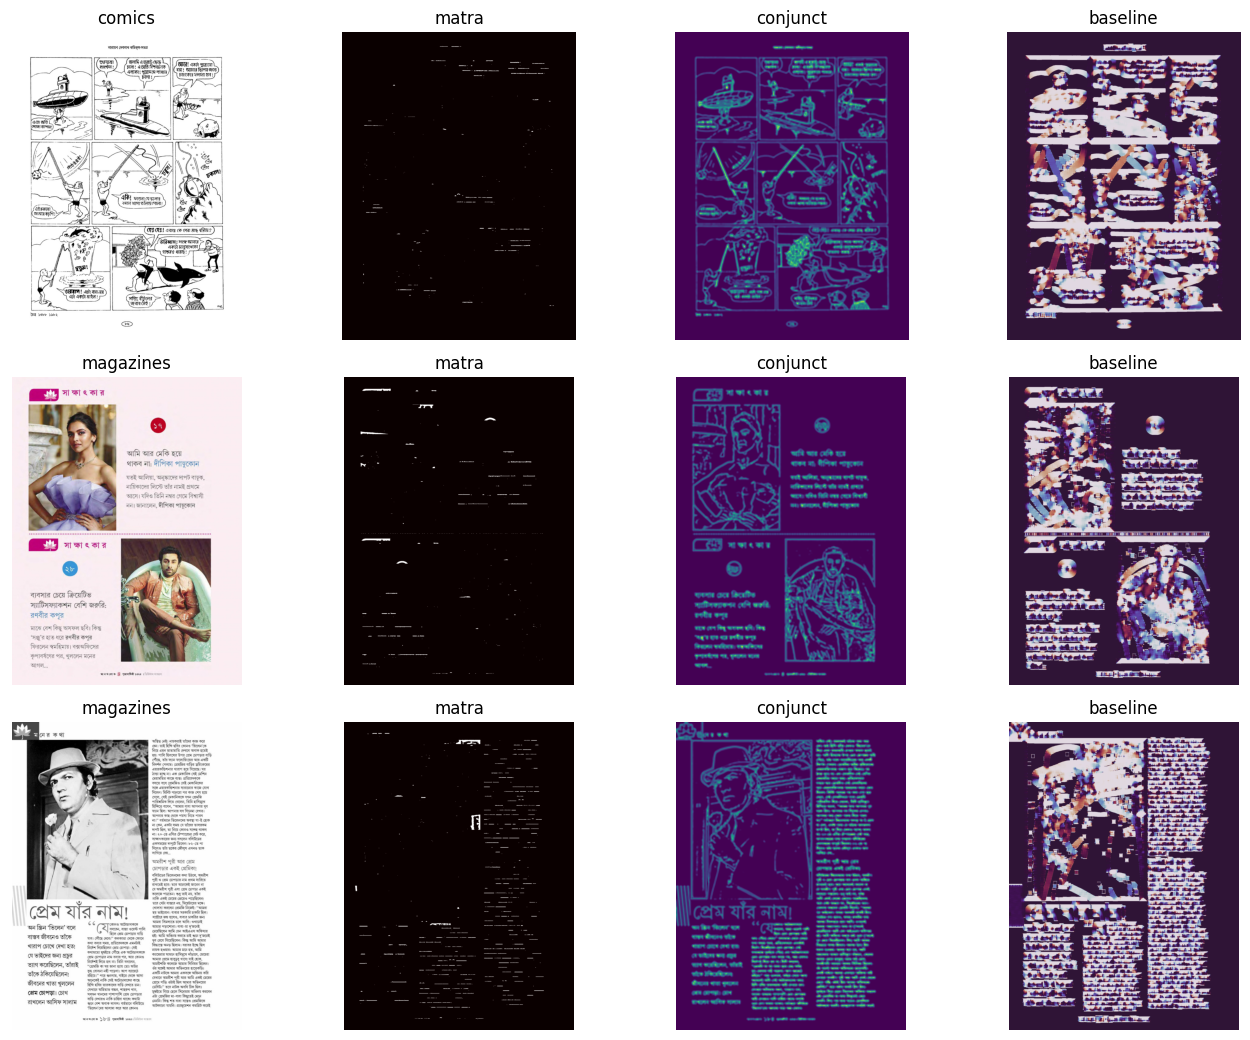

In [11]:
train_items = list_split('train')
sample_paths = random.sample(train_items, min(3, len(train_items)))
fig, axes = plt.subplots(len(sample_paths), 4, figsize=(14, 3.5 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = np.array([axes])
for i, (p, cat) in enumerate(sample_paths):
    img = load_image(p)
    m = matra_map(img); c = conjunct_map(img); b = baseline_orientation_map(img)
    axes[i, 0].imshow(img); axes[i, 0].set_title(f'{cat}')
    axes[i, 1].imshow(m, cmap='hot'); axes[i, 1].set_title('matra')
    axes[i, 2].imshow(c, cmap='viridis'); axes[i, 2].set_title('conjunct')
    axes[i, 3].imshow(b, cmap='twilight'); axes[i, 3].set_title('baseline')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pseudo_label_samples.png', dpi=120)
plt.show()


## 6. SSA-Embed model — SigLIP2 backbone + 3 aux heads + projection

In [12]:
from transformers import AutoModel, AutoProcessor

SIGLIP_ID = 'google/siglip2-base-patch16-384'

processor = AutoProcessor.from_pretrained(SIGLIP_ID)
backbone_full = AutoModel.from_pretrained(SIGLIP_ID)
vision = backbone_full.vision_model

HIDDEN = vision.config.hidden_size
PATCH = vision.config.patch_size
GRID = IMG_SIZE // PATCH
print(f'hidden={HIDDEN}  patch={PATCH}  grid={GRID}x{GRID}')

for p in vision.parameters():
    p.requires_grad = False
for blk in vision.encoder.layers[-2:]:
    for p in blk.parameters():
        p.requires_grad = True

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

hidden=768  patch=16  grid=24x24


In [13]:
class DenseHead(nn.Module):
    def __init__(self, in_dim: int, out_ch: int = 1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2), nn.GELU(),
            nn.Linear(in_dim // 2, out_ch),
        )
    def forward(self, tokens):
        return self.proj(tokens)

class SSAEmbed(nn.Module):
    def __init__(self, vision_tower, hidden: int, embed_dim: int = EMBED_DIM, grid: int = GRID):
        super().__init__()
        self.vision = vision_tower
        self.grid = grid
        self.hidden = hidden
        self.proj = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, embed_dim),
        )
        self.head_matra    = DenseHead(hidden, 1)
        self.head_conj     = DenseHead(hidden, 1)
        self.head_baseline = DenseHead(hidden, 1)

    def _tokens(self, pixel_values):
        out = self.vision(pixel_values=pixel_values, output_hidden_states=False, return_dict=True)
        tokens = out.last_hidden_state
        pooled = tokens.mean(dim=1)
        return tokens, pooled

    def forward(self, pixel_values, return_dense: bool = False):
        tokens, pooled = self._tokens(pixel_values)
        emb = F.normalize(self.proj(pooled), dim=-1)
        if not return_dense:
            return emb
        def as_map(h):
            y = h(tokens).squeeze(-1)
            y = y.view(-1, self.grid, self.grid).unsqueeze(1)
            return y
        return emb, {
            'matra':    as_map(self.head_matra),
            'conj':     as_map(self.head_conj),
            'baseline': as_map(self.head_baseline),
            'tokens':   tokens,
        }

model = SSAEmbed(vision, HIDDEN).to(DEVICE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable params: {n_trainable/1e6:.2f} M')


trainable params: 15.46 M


In [14]:
def bce_map(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.binary_cross_entropy_with_logits(pred.squeeze(1), target)

def mse_map(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(pred.squeeze(1), target)


In [15]:
def augment_view(img_rgb: np.ndarray) -> np.ndarray:
    H, W = img_rgb.shape[:2]
    angle = float(np.random.uniform(-8, 8))
    M = cv2.getRotationMatrix2D((W / 2, H / 2), angle, 1.0)
    img = cv2.warpAffine(img_rgb, M, (W, H), borderMode=cv2.BORDER_REPLICATE)
    alpha = float(np.random.uniform(0.7, 1.3))
    beta  = float(np.random.uniform(-25, 25))
    img = np.clip(alpha * img.astype(np.float32) + beta, 0, 255).astype(np.uint8)
    if np.random.rand() < 0.4:
        k = int(np.random.choice([3, 5, 7]))
        img = cv2.GaussianBlur(img, (k, k), 0)
    q = int(np.random.randint(40, 90))
    enc = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                       [int(cv2.IMWRITE_JPEG_QUALITY), q])[1]
    img = cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    return img

def instance_infonce(z1: torch.Tensor, z2: torch.Tensor, tau: float = 0.07) -> torch.Tensor:
    z1 = F.normalize(z1, dim=-1); z2 = F.normalize(z2, dim=-1)
    sim = z1 @ z2.t() / tau
    tgt = torch.arange(sim.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(sim, tgt) + F.cross_entropy(sim.t(), tgt))

def distill_cos(student: torch.Tensor, teacher: torch.Tensor) -> torch.Tensor:
    s = F.normalize(student, dim=-1); t = F.normalize(teacher, dim=-1)
    return (1.0 - (s * t).sum(-1)).mean()

class PageWithViewDataset(DocDataset):
    def __getitem__(self, idx):
        path, cat = self.items[idx]
        img = load_image(path)
        sample = {'image': to_tensor(img, self.size),
                  'view':  to_tensor(augment_view(img), self.size),
                  'label': CAT2ID[cat], 'path': str(path)}
        if self.return_pseudo:
            m, c, b = pseudo_labels(img, out_size=self.size // 16)
            sample['matra'] = torch.from_numpy(m).float()
            sample['conj']  = torch.from_numpy(c).float()
            sample['baseline'] = torch.from_numpy(b).float()
        return sample


## 7. SSA-Embed training — instance-InfoNCE + SigLIP2 distillation

Trains SSA-Embed from a **fresh** SigLIP2 backbone with:

$$\mathcal{L} = \mathcal{L}_{\text{InfoNCE}}(view_1, view_2)
             + \lambda_d\,\mathcal{L}_{\text{distill}}(student, siglip2_\text{frozen})
             + \lambda_a\,(\mathcal{L}_\text{matra} + \mathcal{L}_\text{conj} + \mathcal{L}_\text{baseline})$$

- The two InfoNCE positives are independently augmented views of the same page — the model learns to give every page a distinct fingerprint that survives augmentation.
- The distillation term keeps the ViT features close to zero-shot SigLIP2, so V2 cannot fall below the strong pretrained baseline.
- The SSA aux losses are weighted low (0.1 / 0.1 / 0.05) so they nudge without dominating.

Gradient updates use the `train` split only. The `val` split drives model selection (best-val checkpoint). The `test` split is held out for all evaluation.


In [16]:
def _atomic_torch_save(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    with open(tmp, 'wb') as f:
        torch.save(obj, f)
        f.flush()
        try:
            os.fsync(f.fileno())
        except OSError:
            pass
    os.replace(tmp, path)

def _prune_epoch_ckpts(dir_: Path, pattern: str, keep: Optional[Path] = None) -> int:
    keep_r = keep.resolve() if keep is not None else None
    removed = 0
    for old in Path(dir_).glob(pattern):
        if keep_r is not None and old.resolve() == keep_r:
            continue
        try:
            old.unlink(); removed += 1
        except OSError:
            pass
    return removed

def _cleanup_epoch_ckpts(dir_: Path, pattern: str) -> int:
    return _prune_epoch_ckpts(dir_, pattern, keep=None)

def _disk_free_gb(path: Path) -> float:
    st = os.statvfs(str(path))
    return st.f_bavail * st.f_frsize / (1024 ** 3)


In [17]:
V2_EPOCHS = 8
V2_LR = 2e-4
V2_WD = 1e-4
V2_LAMBDA_D = 1.0
V2_LAMBDA_M, V2_LAMBDA_C, V2_LAMBDA_B = 0.1, 0.1, 0.05
V2_TAU = 0.07

v2_train_ds = PageWithViewDataset('train', return_pseudo=True)
v2_val_ds   = PageWithViewDataset('val',   return_pseudo=True)
print(f'train samples: {len(v2_train_ds)} | val samples: {len(v2_val_ds)}')

v2_train_loader = DataLoader(v2_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, drop_last=True, pin_memory=True,
                             worker_init_fn=seed_worker, generator=make_generator(SEED))
v2_val_loader = DataLoader(v2_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, drop_last=False, pin_memory=True,
                           worker_init_fn=seed_worker, generator=make_generator(SEED))

V2_FINAL  = OUT_DIR / 'ssa_embed_v2.pt'
V2_BEST   = OUT_DIR / 'ssa_embed_v2_best.pt'
V1_COMPAT = OUT_DIR / 'ssa_embed.pt'
V2_EPOCH_GLOB = 'ssa_epoch_v2_*.pt'

def _find_v2_ckpt() -> Tuple[Optional[Path], int]:
    ckpts = sorted(OUT_DIR.glob(V2_EPOCH_GLOB),
                   key=lambda p: int(p.stem.split('_')[-1]))
    return (ckpts[-1], int(ckpts[-1].stem.split('_')[-1])) if ckpts else (None, 0)

def _v2_loss(batch, mdl, teach):
    x1 = batch['image'].to(DEVICE, non_blocking=True)
    x2 = batch['view'].to(DEVICE, non_blocking=True)
    m  = batch['matra'].to(DEVICE)
    c  = batch['conj'].to(DEVICE)
    b  = batch['baseline'].to(DEVICE)
    emb1, aux = mdl(x1, return_dense=True)
    emb2 = mdl(x2)
    pooled1 = aux['tokens'].mean(dim=1)
    with torch.no_grad():
        t_out = teach(pixel_values=x1, return_dict=True)
        teacher_pooled = t_out.last_hidden_state.mean(dim=1)
    l_ins = instance_infonce(emb1, emb2, tau=V2_TAU)
    l_dis = distill_cos(pooled1, teacher_pooled)
    l_m   = bce_map(aux['matra'], m)
    l_c   = bce_map(aux['conj'],  c)
    l_b   = mse_map(aux['baseline'], b)
    total = (l_ins
             + V2_LAMBDA_D * l_dis
             + V2_LAMBDA_M * l_m + V2_LAMBDA_C * l_c + V2_LAMBDA_B * l_b)
    return total, {'total': total, 'ins': l_ins, 'dis': l_dis,
                   'm': l_m, 'c': l_c, 'b': l_b}

@torch.no_grad()
def _v2_val_loss(mdl, teach, loader) -> Dict[str, float]:
    mdl.eval()
    acc = {k: [] for k in ('total', 'ins', 'dis', 'm', 'c', 'b')}
    for batch in loader:
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            _, parts = _v2_loss(batch, mdl, teach)
        for k in acc:
            acc[k].append(float(parts[k].item()))
    return {k: float(np.mean(v)) if v else float('nan') for k, v in acc.items()}

if is_done('train_ssa_v2') and V2_FINAL.exists():
    print('Training already complete - loading best-val weights.')
    model.load_state_dict(torch.load(V2_FINAL, map_location=DEVICE))
    _cleanup_epoch_ckpts(OUT_DIR, V2_EPOCH_GLOB)
else:
    ckpt_path, ep = _find_v2_ckpt()
    if ckpt_path is None:
        _fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
        model = SSAEmbed(_fresh_vision, HIDDEN).to(DEVICE)
        for p in model.vision.parameters(): p.requires_grad = False
        for blk in model.vision.encoder.layers[-2:]:
            for p in blk.parameters(): p.requires_grad = True
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'trainable params: {n_trainable/1e6:.2f} M')

    teacher = AutoModel.from_pretrained(SIGLIP_ID).vision_model.to(DEVICE).eval()
    for p in teacher.parameters(): p.requires_grad = False

    v2_opt   = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                 lr=V2_LR, weight_decay=V2_WD)
    v2_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        v2_opt, T_max=V2_EPOCHS * max(1, len(v2_train_loader)))
    v2_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    start_epoch = 0
    best_val = float('inf')
    if ckpt_path is not None:
        print(f'Resuming from {ckpt_path.name} (completed epoch {ep})')
        st = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(st['model'])
        v2_opt.load_state_dict(st['opt'])
        try:
            v2_sched.load_state_dict(st['sched'])
            v2_scaler.load_state_dict(st['scaler'])
        except Exception as e:
            print('scheduler/scaler state skipped:', e)
        start_epoch = ep
        best_val = float(st.get('best_val_loss', best_val))

    v2_hist_path = OUT_DIR / 'train_history_v2.json'
    v2_hist = json.loads(v2_hist_path.read_text()) if v2_hist_path.exists() else []
    for h in v2_hist:
        if h.get('val_loss') is not None and h['val_loss'] < best_val:
            best_val = float(h['val_loss'])

    for epoch in range(start_epoch, V2_EPOCHS):
        model.train()
        pbar = tqdm(v2_train_loader, desc=f'epoch {epoch+1}/{V2_EPOCHS}')
        tr = []
        for batch in pbar:
            v2_opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                loss, parts = _v2_loss(batch, model, teacher)
            v2_scaler.scale(loss).backward()
            v2_scaler.step(v2_opt); v2_scaler.update(); v2_sched.step()
            tr.append(float(loss.item()))
            pbar.set_postfix(ins=f'{parts["ins"].item():.3f}',
                             dis=f'{parts["dis"].item():.3f}',
                             m=f'{parts["m"].item():.3f}')

        v = _v2_val_loss(model, teacher, v2_val_loader)
        tr_mean = float(np.mean(tr)) if tr else float('nan')
        print(f"  epoch {epoch+1}: train={tr_mean:.4f}  val={v['total']:.4f}  "
              f"val_ins={v['ins']:.4f}  val_dis={v['dis']:.4f}")

        epoch_ckpt = OUT_DIR / f'ssa_epoch_v2_{epoch+1}.pt'
        _atomic_torch_save({'model':  model.state_dict(),
                            'opt':    v2_opt.state_dict(),
                            'sched':  v2_sched.state_dict(),
                            'scaler': v2_scaler.state_dict(),
                            'best_val_loss': best_val,
                            }, epoch_ckpt)
        _prune_epoch_ckpts(OUT_DIR, V2_EPOCH_GLOB, keep=epoch_ckpt)

        if v['total'] < best_val:
            best_val = float(v['total'])
            _atomic_torch_save(model.state_dict(), V2_BEST)
            _atomic_torch_save(model.state_dict(), V2_FINAL)
            _atomic_torch_save(model.state_dict(), V1_COMPAT)
            print(f'  -> new best val_loss={best_val:.4f}, saved {V2_BEST.name}')

        v2_hist.append({'epoch': epoch + 1,
                        'train_loss': tr_mean,
                        'val_loss': v['total'],
                        'val_ins': v['ins'], 'val_dis': v['dis'],
                        'val_m': v['m'], 'val_c': v['c'], 'val_b': v['b'],
                        'best_val_loss': best_val})
        v2_hist_path.write_text(json.dumps(v2_hist, indent=2))

    if V2_FINAL.exists():
        model.load_state_dict(torch.load(V2_FINAL, map_location=DEVICE))
        print(f'loaded best-val weights from {V2_FINAL.name} (val_loss={best_val:.4f})')

    del teacher; torch.cuda.empty_cache()
    _cleanup_epoch_ckpts(OUT_DIR, V2_EPOCH_GLOB)
    mark_done('train_ssa_v2', {'epochs': V2_EPOCHS,
                               'path': str(V2_FINAL),
                               'best_val_loss': best_val})


train samples: 8035 | val samples: 2009
Training already complete - loading best-val weights.


In [18]:
# if is_done('train_ssa_v2') and not is_done('snapshot_v2_training'):
#     _snapshot('v2_training')


## 8. Build the FAISS gallery over the test split

We embed the test set once, save the embeddings to disk, and build a FAISS `IndexFlatIP` (cosine similarity, since embeddings are L2-normalized).

In [20]:
test_ds = DocDataset('test', return_pseudo=False)
print(f'test samples: {len(test_ds)}')

@torch.no_grad()
def embed_dataset(mdl: nn.Module, ds: Dataset, batch_size: int = BATCH_SIZE) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    mdl.eval()
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        worker_init_fn=seed_worker, generator=make_generator(SEED))
    embs, labs, paths = [], [], []
    for batch in tqdm(loader, desc='embed'):
        x = batch['image'].to(DEVICE, non_blocking=True)
        e = mdl(x)
        embs.append(e.detach().cpu().numpy().astype('float32'))
        labs.append(batch['label'].numpy())
        paths.extend(batch['path'])
    return np.concatenate(embs, 0), np.concatenate(labs, 0), paths

def l2_normalize(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True) + 1e-12
    return x / n

def build_faiss(embs: np.ndarray) -> faiss.Index:
    d = embs.shape[1]
    idx = faiss.IndexFlatIP(d)
    idx.add(embs.astype('float32'))
    return idx

EMB_PATH   = OUT_DIR / 'test_embeddings.npy'
LAB_PATH   = OUT_DIR / 'test_labels.npy'
PATHS_PATH = OUT_DIR / 'test_paths.json'
FAISS_PATH = OUT_DIR / 'faiss_test.index'

def load_gallery():
    embs = np.load(EMB_PATH)
    labs = np.load(LAB_PATH)
    paths = json.loads(PATHS_PATH.read_text())
    idx = faiss.read_index(str(FAISS_PATH))
    return embs, labs, paths, idx

if is_done('embed_test') and all(p.exists() for p in [EMB_PATH, LAB_PATH, PATHS_PATH, FAISS_PATH]):
    test_emb, test_lab, test_paths, faiss_test = load_gallery()
else:
    test_emb, test_lab, test_paths = embed_dataset(model, test_ds)
    test_emb = l2_normalize(test_emb)
    np.save(EMB_PATH, test_emb)
    np.save(LAB_PATH, test_lab)
    PATHS_PATH.write_text(json.dumps(test_paths))
    faiss_test = build_faiss(test_emb)
    faiss.write_index(faiss_test, str(FAISS_PATH))
    mark_done('embed_test', {'n': int(len(test_emb)), 'd': int(test_emb.shape[1])})

print('gallery:', test_emb.shape, '| index size:', faiss_test.ntotal)


test samples: 6047
gallery: (6047, 512) | index size: 6047


## 9. Retrieval evaluation — instance-level (FAISS-based)

Each test image is used **twice**: a lightly-augmented copy is the **query**, and the clean copy is in the **gallery**. A hit means the top-K result contains the *exact same source image*, not just the same genre. This is the only self-retrieval number that actually measures retrieval quality — the earlier category-match version trivially saturates at 1.0 because the model was trained on those 7 labels.


In [21]:
def faiss_search(idx: faiss.Index, queries: np.ndarray, topk: int) -> np.ndarray:
    queries = queries.astype('float32')
    _, I = idx.search(queries, topk)
    return I

class InstanceQueryDataset(Dataset):
    def __init__(self, base_items, size: int = IMG_SIZE):
        self.items = base_items
        self.size = size
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p, cat = self.items[i]
        img = load_image(p)
        rng = np.random.RandomState(SEED + i)
        angle = float(rng.uniform(-3, 3))
        H, W = img.shape[:2]
        M = cv2.getRotationMatrix2D((W / 2, H / 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (W, H), borderMode=cv2.BORDER_REPLICATE)
        img = cv2.GaussianBlur(img, (3, 3), 0)
        alpha = float(rng.uniform(0.9, 1.1))
        beta  = float(rng.uniform(-10, 10))
        img = np.clip(alpha * img.astype(np.float32) + beta, 0, 255).astype(np.uint8)
        enc = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                           [int(cv2.IMWRITE_JPEG_QUALITY), 70])[1]
        img = cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        return {'image': to_tensor(img, self.size),
                'label': CAT2ID[cat], 'src_idx': i, 'path': str(p)}

@torch.no_grad()
def embed_instance_queries(mdl: nn.Module, ds: Dataset):
    mdl.eval()
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        worker_init_fn=seed_worker, generator=make_generator(SEED))
    embs, src_idxs, labs = [], [], []
    for batch in tqdm(loader, desc='instance queries'):
        e = mdl(batch['image'].to(DEVICE, non_blocking=True))
        embs.append(e.detach().cpu().numpy().astype('float32'))
        src_idxs.append(batch['src_idx'].numpy())
        labs.append(batch['label'].numpy())
    return (l2_normalize(np.concatenate(embs, 0)),
            np.concatenate(src_idxs, 0),
            np.concatenate(labs, 0))

def instance_metrics(q_emb: np.ndarray, q_src: np.ndarray,
                     g_idx: faiss.Index, ks=(1, 5, 10)) -> Dict[str, float]:
    topk = min(g_idx.ntotal, max(max(ks), 100))
    I = faiss_search(g_idx, q_emb, topk)
    match = (I == q_src[:, None])
    out = {f'R@{k}': float(match[:, :k].any(axis=1).mean()) for k in ks}
    hit_any = match.any(1)
    ranks = np.where(hit_any, match.argmax(1) + 1, topk + 1)
    out['MRR'] = float((1.0 / ranks).mean())
    ap = np.where(hit_any, 1.0 / np.clip(ranks, 1, None), 0.0)
    out['mAP'] = float(ap.mean())
    if hit_any.any():
        out['median_rank'] = float(np.median(ranks[hit_any]))
    else:
        out['median_rank'] = float('nan')
    return out

def compute_cmc(q_emb: np.ndarray, q_src: np.ndarray,
                g_idx: faiss.Index, max_k: Optional[int] = None) -> np.ndarray:
    if max_k is None:
        max_k = g_idx.ntotal
    topk = min(g_idx.ntotal, int(max_k))
    I = faiss_search(g_idx, q_emb, topk)
    match = (I == q_src[:, None])
    cmc = np.zeros(topk, dtype=np.float64)
    hit_so_far = np.zeros(len(q_emb), dtype=bool)
    for k in range(topk):
        hit_so_far |= match[:, k]
        cmc[k] = hit_so_far.mean()
    return cmc

test_items_ordered = [(Path(p), CATEGORIES[int(l)])
                      for p, l in zip(test_paths, test_lab)]
instance_qs = InstanceQueryDataset(test_items_ordered)

q_emb, q_src, q_lab = embed_instance_queries(model, instance_qs)

ssa_full_page = instance_metrics(q_emb, q_src, faiss_test)
print('SSA-Embed instance-level self-retrieval (test split):', ssa_full_page)

ssa_per_genre = []
for cid, cname in ID2CAT.items():
    mask = q_lab == cid
    if mask.sum() < 2:
        continue
    r = instance_metrics(q_emb[mask], q_src[mask], faiss_test)
    r['genre'] = cname
    r['n'] = int(mask.sum())
    ssa_per_genre.append(r)

pd.DataFrame(ssa_per_genre)


instance queries:   0%|          | 0/378 [00:00<?, ?it/s]

SSA-Embed instance-level self-retrieval (test split): {'R@1': 0.9556805027286258, 'R@5': 0.9909045807838598, 'R@10': 0.9948734909872664, 'MRR': 0.97164141603887, 'mAP': 0.9716397786996772, 'median_rank': 1.0}


,R@1,R@5,R@10,MRR,mAP,median_rank,genre,n
0,0.987692,1.000000,1.000000,0.993846,0.993846,1.0,advertisements,325
1,0.975758,1.000000,1.000000,0.987879,0.987879,1.0,book_covers,165
2,0.900836,0.972521,0.983871,0.932694,0.932688,1.0,books,1674
3,0.994934,1.000000,1.000000,0.997467,0.997467,1.0,comics,987
4,0.933824,0.991728,0.996324,0.960112,0.960112,1.0,magazines,1088
5,0.987109,1.000000,1.000000,0.993247,0.993247,1.0,news_papers,543
6,0.992095,1.000000,1.000000,0.995850,0.995850,1.0,poems,1265


In [22]:
def embedding_collapse_report(embs: np.ndarray, labs: np.ndarray, name: str) -> None:
    embs = embs.astype('float32')
    embs = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-12)
    intra, inter = [], []
    for cid in np.unique(labs):
        m = labs == cid
        if m.sum() < 2:
            continue
        e_in = embs[m]
        if len(e_in) > 512:
            rng = np.random.RandomState(SEED)
            e_in = e_in[rng.choice(len(e_in), 512, replace=False)]
        s = e_in @ e_in.T
        iu = np.triu_indices_from(s, k=1)
        intra.append(s[iu])
        e_out = embs[~m]
        if len(e_out) > 512:
            rng = np.random.RandomState(SEED + 1)
            e_out = e_out[rng.choice(len(e_out), 512, replace=False)]
        inter.append((e_in @ e_out.T).ravel())
    intra = np.concatenate(intra); inter = np.concatenate(inter)
    s = np.linalg.svd(embs - embs.mean(0), compute_uv=False)
    eff_dim = float((s.sum() ** 2) / (s ** 2).sum())
    print(f'[{name}]  mean_intra_sim={intra.mean():.3f}  '
          f'mean_inter_sim={inter.mean():.3f}  gap={intra.mean() - inter.mean():.3f}  '
          f'effective_dim={eff_dim:.1f} / {embs.shape[1]}')

embedding_collapse_report(test_emb, test_lab, 'SSA-Embed (gallery)')


[SSA-Embed (gallery)]  mean_intra_sim=0.171  mean_inter_sim=0.001  gap=0.170  effective_dim=140.8 / 512


##  12. (E) Degradation robustness evaluation

For each (degradation, severity), apply to every test image (query), keep the gallery clean, and measure Recall@K. Results are appended to `degradation_results.csv` per pair, so if the session dies mid-loop, the next run skips completed pairs.

In [23]:
import albumentations as A

def degradation(name: str, severity: int) -> A.Compose:
    s = severity
    if name == 'blur':
        k = [3, 5, 7, 11, 15][s-1]
        return A.Compose([A.GaussianBlur(blur_limit=(k, k), p=1.0)])
    if name == 'jpeg':
        q = [90, 70, 50, 30, 15][s-1]
        return A.Compose([A.ImageCompression(quality_lower=q, quality_upper=q, p=1.0)])
    if name == 'noise':
        v = [100, 400, 1000, 2500, 5000][s-1]
        return A.Compose([A.GaussNoise(var_limit=(v, v), p=1.0)])
    if name == 'downres':
        r = [0.9, 0.7, 0.5, 0.35, 0.25][s-1]
        return A.Compose([A.Downscale(scale_min=r, scale_max=r,
                                       interpolation=cv2.INTER_AREA, p=1.0)])
    if name == 'illum':
        v = [0.15, 0.3, 0.45, 0.6, 0.75][s-1]
        return A.Compose([A.RandomBrightnessContrast(brightness_limit=(v, v),
                                                     contrast_limit=(v, v), p=1.0)])
    if name == 'skew':
        a = [2, 5, 8, 12, 18][s-1]
        return A.Compose([A.Affine(rotate=(a, a), fit_output=True, p=1.0, cval=255)])
    raise ValueError(name)

DEGRADATIONS = ['blur', 'jpeg', 'noise', 'downres', 'illum', 'skew']
SEVERITIES  = [1, 2, 3, 4, 5]

class DegradedDataset(Dataset):
    def __init__(self, base_items, name: str, severity: int, size: int = IMG_SIZE):
        self.items = base_items
        self.aug = degradation(name, severity)
        self.size = size
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p, cat = self.items[i]
        img = load_image(p)
        img = self.aug(image=img)['image']
        return {'image': to_tensor(img, self.size),
                'label': CAT2ID[cat], 'path': str(p)}


In [24]:
DEG_CSV = OUT_DIR / 'degradation_results.csv'

gallery_emb  = test_emb
gallery_idx  = faiss_test

def _load_done() -> set:
    if not DEG_CSV.exists(): return set()
    df = pd.read_csv(DEG_CSV)
    return set(zip(df['degradation'], df['severity']))

def _append_row(row: dict):
    pd.DataFrame([row]).to_csv(DEG_CSV, mode='a',
                                header=not DEG_CSV.exists(), index=False)

@torch.no_grad()
def deg_sweep(mdl, g_lab, g_idx):
    base = list_split('test')
    done = _load_done()
    src_idx_np = np.arange(len(base))
    total = len(DEGRADATIONS) * len(SEVERITIES)
    pbar = tqdm(total=total, desc='deg sweep')
    for name in DEGRADATIONS:
        for s in SEVERITIES:
            pbar.update(1)
            if (name, s) in done: continue
            ds = DegradedDataset(base, name, s)
            q_emb_d, q_lab_d, _ = embed_dataset(mdl, ds)
            q_emb_d = l2_normalize(q_emb_d)
            topk = min(g_idx.ntotal, 100)
            I = faiss_search(g_idx, q_emb_d, topk)
            match_self = (I == src_idx_np[:, None])
            match_cat  = (g_lab[I] == q_lab_d[:, None])
            row = {'degradation': name, 'severity': s}
            for k in (1, 5, 10):
                row[f'self_R@{k}'] = float(match_self[:, :k].any(1).mean())
                row[f'cat_R@{k}']  = float(match_cat[:, :k].any(1).mean())
            _append_row(row)
    pbar.close()

if is_done('degradation'):
    print('degradation sweep already complete')
else:
    deg_sweep(model, test_lab, gallery_idx)
    mark_done('degradation')

deg_df = pd.read_csv(DEG_CSV).sort_values(['degradation', 'severity']).reset_index(drop=True)
display(deg_df)


degradation sweep already complete


,degradation,severity,self_R@1,cat_R@1,self_R@5,cat_R@5,self_R@10,cat_R@10
0,blur,1,0.998512,0.999835,1.000000,1.000000,1.000000,1.000000
1,blur,2,0.998512,0.999835,1.000000,1.000000,1.000000,1.000000
2,blur,3,0.997850,0.999669,0.999835,1.000000,0.999835,1.000000
3,blur,4,0.996196,0.999504,0.999504,1.000000,0.999669,1.000000
4,blur,5,0.980321,0.998677,0.996031,0.999669,0.998512,1.000000
5,downres,1,0.998512,0.999835,1.000000,1.000000,1.000000,1.000000
6,downres,2,0.998512,0.999835,1.000000,1.000000,1.000000,1.000000
7,downres,3,0.998512,0.999835,1.000000,1.000000,1.000000,1.000000
8,downres,4,0.997354,0.999669,0.999504,1.000000,0.999669,1.000000
9,downres,5,0.993551,0.998677,0.997519,0.999669,0.997850,0.999835


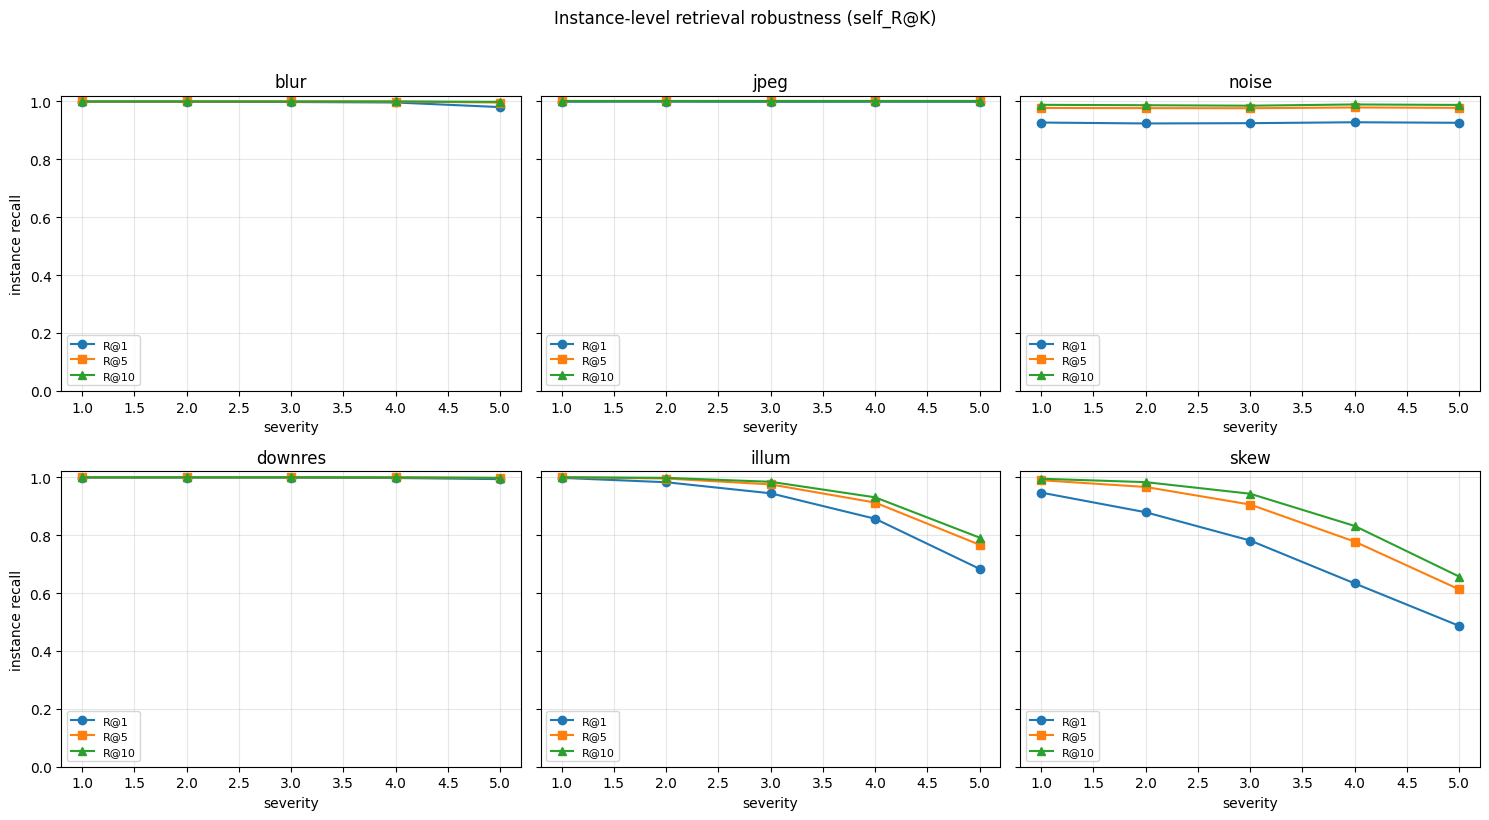

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, name in zip(axes.flat, DEGRADATIONS):
    sub = deg_df[deg_df['degradation'] == name]
    ax.plot(sub['severity'], sub['self_R@1'],  marker='o', label='R@1')
    ax.plot(sub['severity'], sub['self_R@5'],  marker='s', label='R@5')
    ax.plot(sub['severity'], sub['self_R@10'], marker='^', label='R@10')
    ax.set_title(name); ax.set_xlabel('severity'); ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower left')
axes[0, 0].set_ylabel('instance recall'); axes[1, 0].set_ylabel('instance recall')
plt.suptitle('Instance-level retrieval robustness (self_R@K)', y=1.02, fontsize=12)
plt.tight_layout(); plt.savefig(OUT_DIR / 'robustness_curves.png', dpi=140, bbox_inches='tight')
plt.show()


### Appendix: genre-coherence diagnostic (not a retrieval metric)

`cat_R@K` measures whether a degraded query's top-K contains *any* image of the same genre. It's a coarse structural sanity check, **not** retrieval quality — and it's inflated by the fact that the model was trained with those genre labels as sup-con targets. Shown separately so it isn't confused with `self_R@K`.


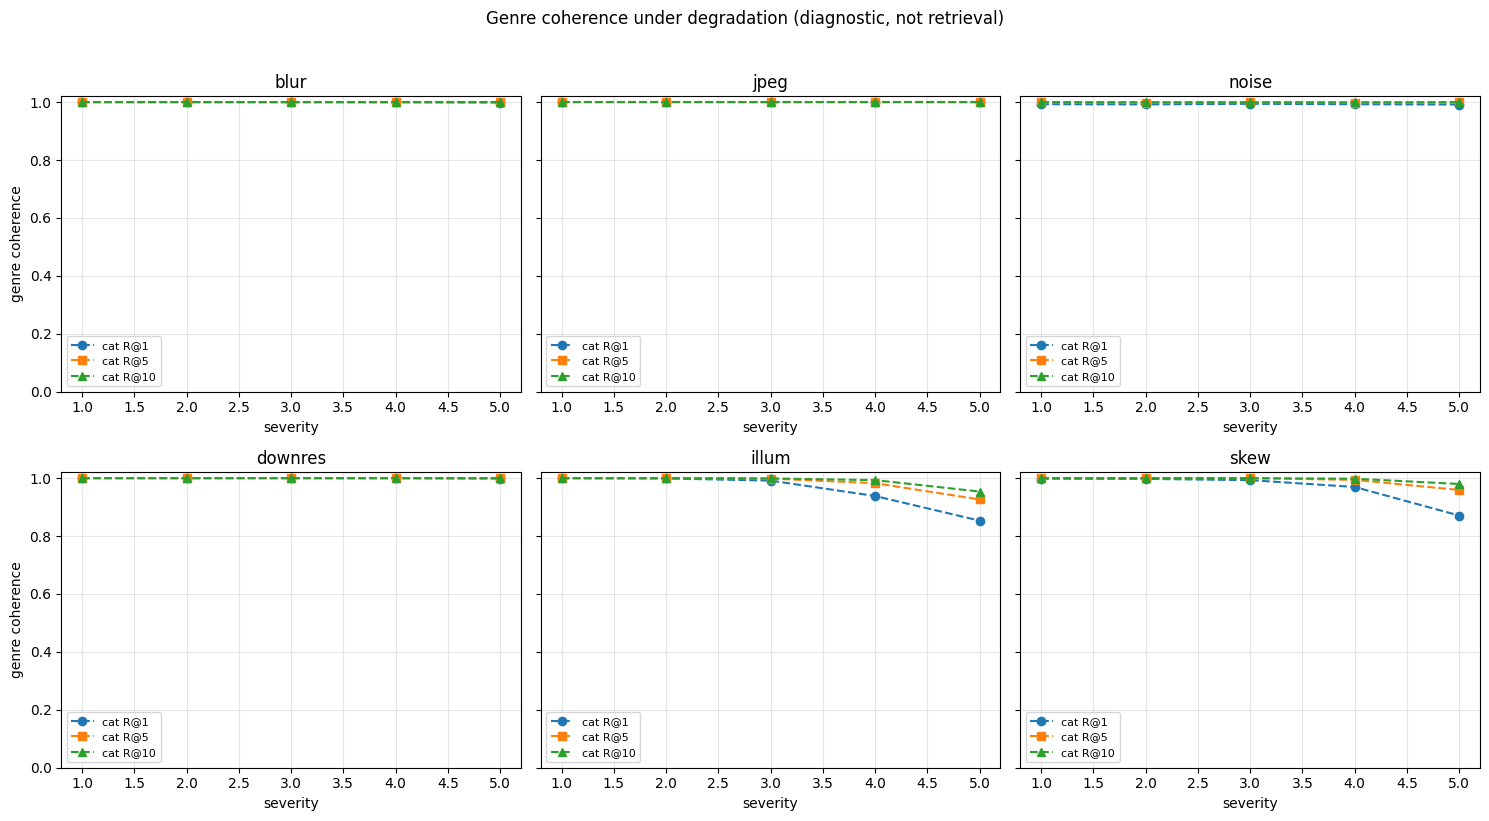

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, name in zip(axes.flat, DEGRADATIONS):
    sub = deg_df[deg_df['degradation'] == name]
    ax.plot(sub['severity'], sub['cat_R@1'],  marker='o', linestyle='--', label='cat R@1')
    ax.plot(sub['severity'], sub['cat_R@5'],  marker='s', linestyle='--', label='cat R@5')
    ax.plot(sub['severity'], sub['cat_R@10'], marker='^', linestyle='--', label='cat R@10')
    ax.set_title(name); ax.set_xlabel('severity'); ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower left')
axes[0, 0].set_ylabel('genre coherence'); axes[1, 0].set_ylabel('genre coherence')
plt.suptitle('Genre coherence under degradation (diagnostic, not retrieval)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'genre_coherence_curves.png', dpi=140, bbox_inches='tight')
plt.show()


In [27]:
# _snapshot('degradation')

## 13. Baselines for comparison (SigLIP2 zero-shot / CLIP / DINOv2)

In [28]:
class VisionEncoderWrapper(nn.Module):
    _CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1)
    _CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1)
    _DONUT_HW  = (1280, 960)

    def __init__(self, hf_model, kind: str):
        super().__init__()
        self.m = hf_model
        self.kind = kind

    def _to_clip(self, x: torch.Tensor) -> torch.Tensor:
        pix = x * 0.5 + 0.5
        pix = F.interpolate(pix, size=224, mode='bilinear', align_corners=False)
        return (pix - self._CLIP_MEAN.to(pix.device)) / self._CLIP_STD.to(pix.device)

    def _to_donut(self, x: torch.Tensor) -> torch.Tensor:
        # Donut normalization (mean=0.5, std=0.5) already matches the SigLIP input tensor.
        return F.interpolate(x, size=self._DONUT_HW, mode='bilinear', align_corners=False)

    def _clip_pooled(self, pixel_values: torch.Tensor) -> torch.Tensor:
        vo = self.m.vision_model(pixel_values=pixel_values, return_dict=True)
        pooled = getattr(vo, 'pooler_output', None)
        if pooled is None:
            pooled = self.m.vision_model.post_layernorm(vo.last_hidden_state[:, 0])
        return self.m.visual_projection(pooled)

    def forward(self, x):
        with torch.no_grad():
            if self.kind == 'siglip':
                o = self.m(pixel_values=x, return_dict=True)
                pooled = o.last_hidden_state.mean(dim=1)
            elif self.kind == 'clip':
                pooled = self._clip_pooled(self._to_clip(x))
            elif self.kind == 'dinov2':
                o = self.m(pixel_values=x, return_dict=True)
                pooled = o.last_hidden_state[:, 0]
            elif self.kind == 'donut':
                o = self.m(pixel_values=self._to_donut(x), return_dict=True)
                pooled = o.last_hidden_state.mean(dim=1)
            else:
                raise ValueError(self.kind)
        return F.normalize(pooled, dim=-1)

def load_baseline(name: str) -> nn.Module:
    if name == 'siglip2_zs':
        m = AutoModel.from_pretrained(SIGLIP_ID).vision_model.to(DEVICE).eval()
        return VisionEncoderWrapper(m, 'siglip')
    if name == 'clip':
        from transformers import CLIPModel
        m = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(DEVICE).eval()
        return VisionEncoderWrapper(m, 'clip')
    if name == 'dinov2':
        m = AutoModel.from_pretrained('facebook/dinov2-base').to(DEVICE).eval()
        return VisionEncoderWrapper(m, 'dinov2')
    if name == 'donut':
        from transformers import VisionEncoderDecoderModel
        full = VisionEncoderDecoderModel.from_pretrained('naver-clova-ix/donut-base')
        m = full.encoder.to(DEVICE).eval()
        del full
        return VisionEncoderWrapper(m, 'donut')
    raise ValueError(name)

def bench_baseline(name: str):
    emb_path   = OUT_DIR / f'baseline_{name}_emb.npy'
    idx_path   = OUT_DIR / f'baseline_{name}.index'
    q_emb_path = OUT_DIR / f'baseline_{name}_qemb.npy'
    q_src_path = OUT_DIR / f'baseline_{name}_qsrc.npy'
    q_lab_path = OUT_DIR / f'baseline_{name}_qlab.npy'

    cached = (is_done(f'baseline_{name}') and
              all(p.exists() for p in (emb_path, idx_path, q_emb_path, q_src_path, q_lab_path)))
    if cached:
        emb   = np.load(emb_path)
        idx   = faiss.read_index(str(idx_path))
        b_qe  = np.load(q_emb_path)
        b_qs  = np.load(q_src_path)
        b_ql  = np.load(q_lab_path)
    else:
        mdl = load_baseline(name)
        emb, _, _ = embed_dataset(mdl, test_ds)
        emb = l2_normalize(emb)
        np.save(emb_path, emb)
        idx = build_faiss(emb)
        faiss.write_index(idx, str(idx_path))
        b_qe, b_qs, b_ql = embed_instance_queries(mdl, instance_qs)
        np.save(q_emb_path, b_qe); np.save(q_src_path, b_qs); np.save(q_lab_path, b_ql)
        del mdl; torch.cuda.empty_cache()
        mark_done(f'baseline_{name}')

    full = instance_metrics(b_qe, b_qs, idx)
    return {'model': name, 'full_page': full,
            'emb': emb, 'idx': idx,
            'q_emb': b_qe, 'q_src': b_qs, 'q_lab': b_ql}

baseline_results = globals().get('baseline_results', {})


### 13.1 Baseline: SigLIP2 zero-shot


In [29]:
try:
    baseline_results['siglip2_zs'] = bench_baseline('siglip2_zs')
    print('siglip2_zs', baseline_results['siglip2_zs']['full_page'])
except Exception as e:
    print(f'skipping siglip2_zs: {e}')


siglip2_zs {'R@1': 0.8956507359021002, 'R@5': 0.9520423350421696, 'R@10': 0.9651066644617166, 'MRR': 0.9209122237182573, 'mAP': 0.9208581915248941, 'median_rank': 1.0}


### 13.2 Baseline: CLIP (openai/clip-vit-large-patch14)


In [30]:
try:
    baseline_results['clip'] = bench_baseline('clip')
    print('clip', baseline_results['clip']['full_page'])
except Exception as e:
    print(f'skipping clip: {e}')


clip {'R@1': 0.7512816272531834, 'R@5': 0.8445510170332396, 'R@10': 0.8774598974698198, 'MRR': 0.7964662186930515, 'mAP': 0.7960519718772667, 'median_rank': 1.0}


### 13.3 Baseline: DINOv2 (facebook/dinov2-base)


In [31]:
try:
    baseline_results['dinov2'] = bench_baseline('dinov2')
    print('dinov2', baseline_results['dinov2']['full_page'])
except Exception as e:
    print(f'skipping dinov2: {e}')


dinov2 {'R@1': 0.6388291714899951, 'R@5': 0.7033239622953531, 'R@10': 0.737886555316686, 'MRR': 0.6737764349158222, 'mAP': 0.6725582545563608, 'median_rank': 1.0}


### 13.3b Baseline: Donut encoder (naver-clova-ix/donut-base)

Donut is a document-understanding transformer (Swin encoder + BART decoder). We use only the Swin encoder and mean-pool its patch tokens. Native input resolution `1280 x 960` is used since Donut's position embeddings are learned for that size; its normalization (mean=0.5, std=0.5) already matches the SigLIP input tensor, so no re-normalization is needed.


In [32]:
try:
    baseline_results['donut'] = bench_baseline('donut')
    print('donut', baseline_results['donut']['full_page'])
except Exception as e:
    print(f'skipping donut: {e}')


donut {'R@1': 0.9631222093600132, 'R@5': 0.9869356705804532, 'R@10': 0.9912353233008103, 'MRR': 0.9737416325017414, 'mAP': 0.9737318084665845, 'median_rank': 1.0}


### 13.4 Full-page comparison — SSA-Embed vs zero-shot baselines

Assembles the full-page instance-retrieval table with one row per model. Re-runs are cheap because every per-baseline result is cached to disk.


In [33]:
for _n in ('siglip2_zs', 'clip', 'dinov2', 'donut'):
    if _n not in baseline_results:
        try:
            baseline_results[_n] = bench_baseline(_n)
        except Exception as e:
            print(f'skipping {_n}: {e}')

# Note: instance_metrics() computes .mean() over ALL queries -> MICRO average.
# Macro (mean-of-per-genre) is added below for genre-imbalanced test sets.
_AGG_METRICS = ('R@1', 'R@5', 'R@10', 'MRR', 'mAP')

def _micro_macro(qemb, qsrc, qlab, idx):
    micro = instance_metrics(qemb, qsrc, idx)
    per_g = {}
    for cid, cname in ID2CAT.items():
        mask = qlab == cid
        if mask.sum() < 2:
            continue
        per_g[cname] = instance_metrics(qemb[mask], qsrc[mask], idx)
    macro = {k: float(np.mean([per_g[g][k] for g in per_g])) for k in _AGG_METRICS}
    return micro, macro

def _agg_row(name, qe, qs, ql, gi):
    micro, macro = _micro_macro(qe, qs, ql, gi)
    row = {'model': name}
    for k in _AGG_METRICS:
        row[f'micro_{k}'] = micro[k]
    for k in _AGG_METRICS:
        row[f'macro_{k}'] = macro[k]
    row['micro_median_rank'] = micro['median_rank']
    return row

_agg_rows = [_agg_row('SSA-Embed', q_emb, q_src, q_lab, faiss_test)]
for _n, _r in baseline_results.items():
    _agg_rows.append(_agg_row(_n, _r['q_emb'], _r['q_src'], _r['q_lab'], _r['idx']))

baseline_full = pd.DataFrame(_agg_rows)
baseline_full.to_csv(OUT_DIR / 'baselines_full_page.csv', index=False)

# Back-compat: keep the original micro-only "full_page" dict shape available.
baseline_full_micro = pd.DataFrame([
    {'model': 'SSA-Embed', **ssa_full_page},
    *[{'model': k, **v['full_page']} for k, v in baseline_results.items()],
])

print('Full-page instance retrieval — MICRO (per-query mean) vs MACRO (mean of per-genre):')
baseline_full


Full-page instance retrieval — MICRO (per-query mean) vs MACRO (mean of per-genre):


,model,micro_R@1,micro_R@5,micro_R@10,micro_MRR,micro_mAP,macro_R@1,macro_R@5,macro_R@10,macro_MRR,macro_mAP,micro_median_rank
0,SSA-Embed,0.955681,0.990905,0.994873,0.971641,0.971640,0.967464,0.994893,0.997171,0.980157,0.980156,1.0
1,siglip2_zs,0.895651,0.952042,0.965107,0.920912,0.920858,0.927134,0.970937,0.979042,0.947039,0.947007,1.0
2,clip,0.751282,0.844551,0.877460,0.796466,0.796052,0.839379,0.909322,0.930496,0.872701,0.872481,1.0
3,dinov2,0.638829,0.703324,0.737887,0.673776,0.672558,0.771304,0.821989,0.845417,0.798048,0.797358,1.0
4,donut,0.963122,0.986936,0.991235,0.973742,0.973732,0.939821,0.973419,0.979881,0.954941,0.954918,1.0


In [34]:
# if len(baseline_results) >= 3 and not is_done('snapshot_baselines'):
#     _snapshot('baselines')


### 13a. Cross-model comparison — every table with SigLIP2-zs / CLIP / DINOv2 / Donut side-by-side

The full-page table above already compares all five models, but per-genre and degradation curves so far only show SSA-Embed. Below we repeat those tables with baselines alongside so it's obvious *where* SSA-Embed is actually helping and where it just tracks the pretrained backbones.

**Same-seed, same-holdout guarantee.** Every cell below reuses the exact `test_ds`, `instance_qs`, and `test_lab` objects that were built once from `SEED = 42` at the top of the notebook, and the per-baseline gallery embeddings + FAISS indices cached in `13.1` / `13.2` / `13.3` / `13.3b`. Splitting the work across cells does not change any dataset or split — it only lets you run one slow section (e.g. a single baseline's degradation sweep) at a time, and safely resume after a Kaggle session timeout.

**Split map** (each section runs and caches independently):
- `13.5` Per-genre R@1
- `13.7` Degradation-sweep helpers (fast; just definitions)
- `13.8` Degradation sweep — SigLIP2-zs
- `13.9` Degradation sweep — CLIP
- `13.10` Degradation sweep — DINOv2
- `13.10b` Degradation sweep — Donut
- `13.11` Curves + severity-3 summary plot

**What to look for**
- **Per-genre R@1** — SSA-Embed should be ≥ `siglip2_zs` on every genre, especially the low-count / text-heavy ones (poems, comics). If it drops below on a genre, the training hurt that slice.
- **Degradation robustness** — SSA-Embed should decay more slowly than baselines, especially under `blur`, `noise`, and `downres` (where text-structure features survive but photographic features don't).

Degradation runs for baselines are cached per (model, degradation, severity), so a session timeout is safe — re-running skips completed pairs.


In [35]:
from IPython.display import display

MODELS_TO_COMPARE = [
    ('SSA-Embed', q_emb, q_src, q_lab, faiss_test),
]
for _name, _res in baseline_results.items():
    MODELS_TO_COMPARE.append((_name, _res['q_emb'], _res['q_src'], _res['q_lab'], _res['idx']))

def _per_genre_r1(qemb, qsrc, qlab, idx):
    out = {}
    for cid, cname in ID2CAT.items():
        mask = qlab == cid
        if mask.sum() < 2:
            out[cname] = float('nan'); continue
        out[cname] = instance_metrics(qemb[mask], qsrc[mask], idx)['R@1']
    return out

per_genre_rows = []
for genre in CATEGORIES:
    row = {'genre': genre}
    for mname, qe, qs, ql, gi in MODELS_TO_COMPARE:
        row[mname] = _per_genre_r1(qe, qs, ql, gi)[genre]
    per_genre_rows.append(row)
per_genre_comp = pd.DataFrame(per_genre_rows)
per_genre_comp.to_csv(OUT_DIR / 'per_genre_comparison.csv', index=False)
print('Per-genre instance R@1 (higher = better):')
display(per_genre_comp)

_model_cols = [m[0] for m in MODELS_TO_COMPARE]

# Micro R@1 = mean over ALL queries (weighted by genre size). Macro R@1 = mean of per-genre R@1.
micro_r1 = {m: float(instance_metrics(qe, qs, gi)['R@1'])
            for m, qe, qs, _, gi in MODELS_TO_COMPARE}
macro_r1 = {m: float(np.nanmean(per_genre_comp[m].values)) for m in _model_cols}
wins = {m: int((per_genre_comp[_model_cols].idxmax(axis=1) == m).sum()) for m in _model_cols}

summary_rows = [
    {'genre': 'Micro-avg R@1', **micro_r1},
    {'genre': 'Macro-avg R@1', **macro_r1},
    {'genre': 'Genre wins (out of {})'.format(len(CATEGORIES)), **wins},
]
per_genre_summary = pd.DataFrame(summary_rows)
per_genre_summary.to_csv(OUT_DIR / 'per_genre_summary.csv', index=False)
print('\nAggregate summary (micro = per-query mean, macro = mean of per-genre):')
display(per_genre_summary)

best_micro = max(micro_r1, key=micro_r1.get)
best_macro = max(macro_r1, key=macro_r1.get)
print(f'\nBest by MICRO R@1: {best_micro} ({micro_r1[best_micro]:.4f})')
print(f'Best by MACRO R@1: {best_macro} ({macro_r1[best_macro]:.4f})')
if best_micro != best_macro:
    print('NOTE: micro and macro disagree -> test-set genre imbalance matters. '
          'For a balanced multi-genre benchmark, macro is the fairer aggregate.')


Per-genre instance R@1 (higher = better):


,genre,SSA-Embed,siglip2_zs,clip,dinov2,donut
0,advertisements,0.987692,0.960000,0.941538,0.953846,0.941538
1,book_covers,0.975758,0.975758,0.975758,0.975758,0.842424
2,books,0.900836,0.775986,0.452210,0.310633,0.974910
3,comics,0.994934,0.991895,0.968592,0.988855,0.951368
4,magazines,0.933824,0.852941,0.818934,0.793199,0.970588
5,news_papers,0.987109,0.981584,0.972376,0.981584,0.898711
6,poems,0.992095,0.951779,0.746245,0.395257,0.999209



Aggregate summary (micro = per-query mean, macro = mean of per-genre):


,genre,SSA-Embed,siglip2_zs,clip,dinov2,donut
0,Micro-avg R@1,0.955681,0.895651,0.751282,0.638829,0.963122
1,Macro-avg R@1,0.967464,0.927134,0.839379,0.771304,0.939821
2,Genre wins (out of 7),4.000000,0.000000,0.000000,0.000000,3.000000



Best by MICRO R@1: donut (0.9631)
Best by MACRO R@1: SSA-Embed (0.9675)
NOTE: micro and macro disagree -> test-set genre imbalance matters. For a balanced multi-genre benchmark, macro is the fairer aggregate.


### 13.7 Degradation sweep — helpers

Fast cell. Defines `_deg_sweep` + `_run_baseline_deg_sweep` used by the per-baseline sweep cells below. All sweeps append to a per-model CSV, so any single (degradation, severity) pair is the smallest unit of work you can lose to a session timeout.


In [36]:
def _load_done_deg(path):
    if not path.exists(): return set()
    df = pd.read_csv(path)
    return set(zip(df['degradation'], df['severity']))

def _append_deg(path, row):
    pd.DataFrame([row]).to_csv(path, mode='a', header=not path.exists(), index=False)

@torch.no_grad()
def _deg_sweep(mdl, g_lab, g_idx, csv_path, tag):
    base = list_split('test')
    done = _load_done_deg(csv_path)
    src_idx_np = np.arange(len(base))
    total = len(DEGRADATIONS) * len(SEVERITIES)
    pbar = tqdm(total=total, desc=f'deg {tag}')
    for name in DEGRADATIONS:
        for s in SEVERITIES:
            pbar.update(1)
            if (name, s) in done: continue
            ds = DegradedDataset(base, name, s)
            q_emb_d, q_lab_d, _ = embed_dataset(mdl, ds)
            q_emb_d = l2_normalize(q_emb_d)
            topk = min(g_idx.ntotal, 100)
            I = faiss_search(g_idx, q_emb_d, topk)
            match_self = (I == src_idx_np[:, None])
            match_cat  = (g_lab[I] == q_lab_d[:, None])
            row = {'degradation': name, 'severity': s}
            for k in (1, 5, 10):
                row[f'self_R@{k}'] = float(match_self[:, :k].any(1).mean())
                row[f'cat_R@{k}']  = float(match_cat[:, :k].any(1).mean())
            _append_deg(csv_path, row)
    pbar.close()

def _run_baseline_deg_sweep(_name):
    _csv_path = OUT_DIR / f'degradation_{_name}.csv'
    if is_done(f'degradation_baseline_{_name}') and _csv_path.exists():
        print(f'degradation_{_name}: already complete')
        return
    if _name not in baseline_results:
        print(f'skipping degradation_{_name}: baseline not benchmarked yet')
        return
    _mdl = load_baseline(_name)
    _deg_sweep(_mdl, test_lab, baseline_results[_name]['idx'], _csv_path, tag=_name)
    del _mdl; torch.cuda.empty_cache()
    mark_done(f'degradation_baseline_{_name}')


In [37]:
# _snapshot('baselines')

### 13.8 Degradation sweep — SigLIP2 zero-shot

Resumable per (degradation, severity).


In [38]:
_run_baseline_deg_sweep('siglip2_zs')


degradation_siglip2_zs: already complete


### 13.9 Degradation sweep — CLIP

Resumable per (degradation, severity).


In [39]:
_run_baseline_deg_sweep('clip')


degradation_clip: already complete


### 13.10 Degradation sweep — DINOv2

Resumable per (degradation, severity). Interrupting mid-sweep only loses the current pair; re-running the cell picks up from `degradation_dinov2.csv`.


In [40]:
_run_baseline_deg_sweep('dinov2')


degradation_dinov2: already complete


In [41]:
# _snapshot('degredation_dinov2')

### 13.10b Degradation sweep — Donut

Resumable per (degradation, severity).


In [42]:
_run_baseline_deg_sweep('donut')


degradation_donut: already complete


In [43]:
# _snapshot('degradation_donutv0')

### 13.11 Degradation curves + severity-3 summary


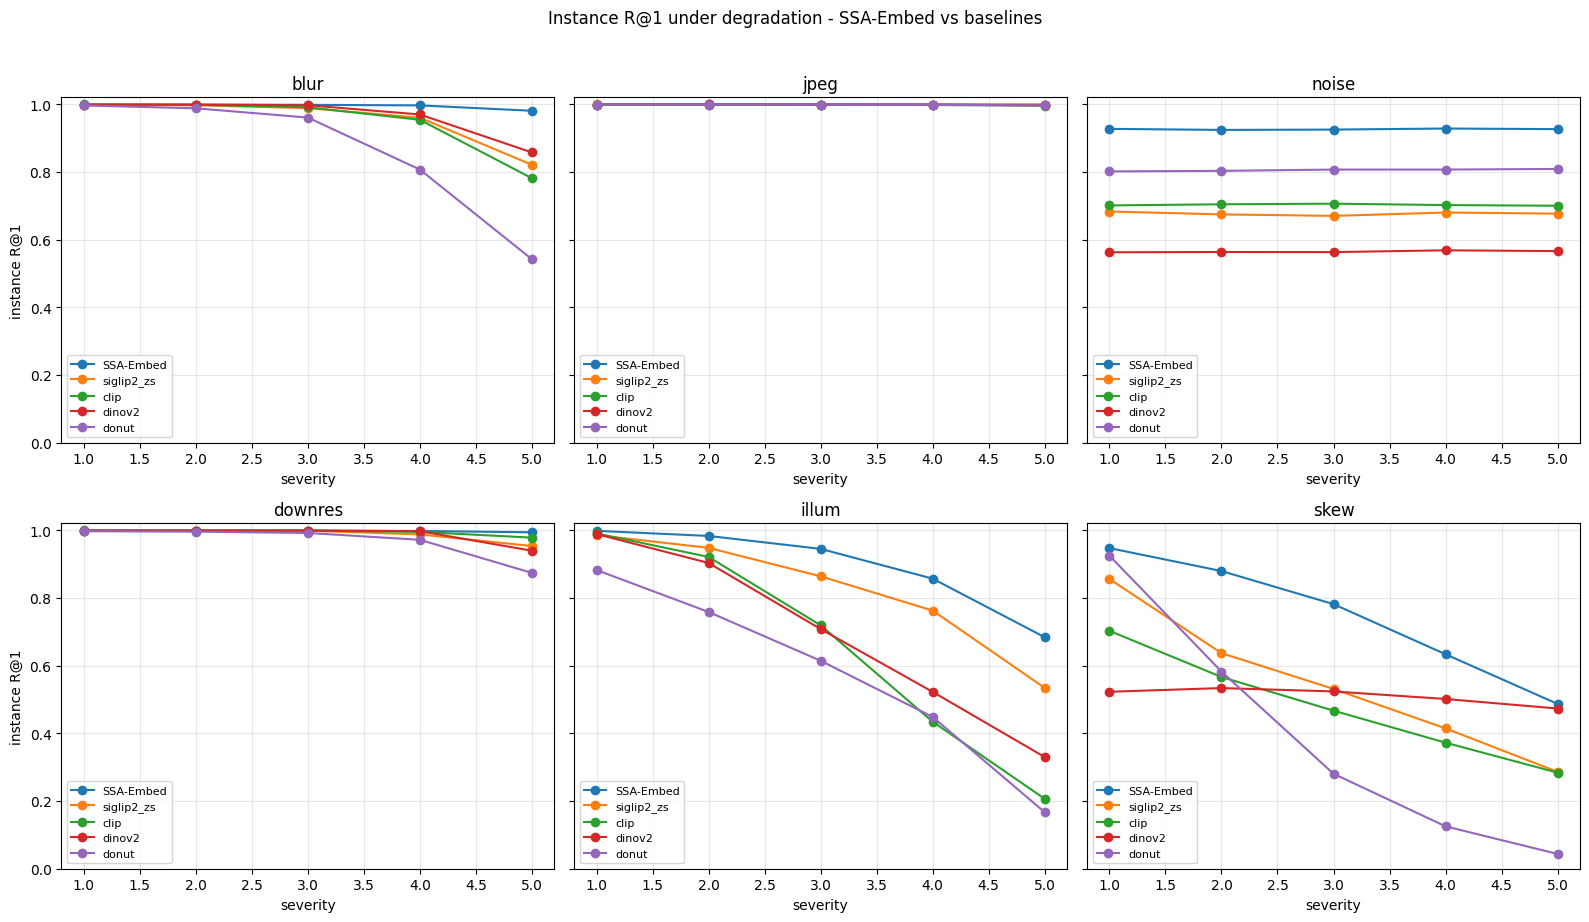

Instance R@1 at severity 3 (moderate) across all degradations:


,model,blur,jpeg,noise,downres,illum,skew
0,SSA-Embed,0.997850,0.998512,0.924756,0.998512,0.944601,0.781379
1,siglip2_zs,0.988259,0.998512,0.669919,0.998181,0.863569,0.530842
2,clip,0.990574,0.998346,0.705970,0.998677,0.718869,0.466843
3,dinov2,0.996693,0.998512,0.562924,0.998512,0.707789,0.523565
4,donut,0.960311,0.998512,0.806681,0.991566,0.614189,0.280470


In [44]:
model_csvs = {'SSA-Embed': DEG_CSV,
              **{name: OUT_DIR / f'degradation_{name}.csv' for name in baseline_results}}
model_curves = {n: pd.read_csv(p).sort_values(['degradation', 'severity']).reset_index(drop=True)
                for n, p in model_csvs.items() if p.exists()}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
COLORS = {'SSA-Embed': 'C0', 'siglip2_zs': 'C1', 'clip': 'C2', 'dinov2': 'C3', 'donut': 'C4'}
for ax, deg_name in zip(axes.flat, DEGRADATIONS):
    for mname, df in model_curves.items():
        sub = df[df['degradation'] == deg_name]
        ax.plot(sub['severity'], sub['self_R@1'], marker='o',
                color=COLORS.get(mname, 'k'), label=mname)
    ax.set_title(deg_name); ax.set_xlabel('severity'); ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower left')
axes[0, 0].set_ylabel('instance R@1'); axes[1, 0].set_ylabel('instance R@1')
plt.suptitle('Instance R@1 under degradation - SSA-Embed vs baselines', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'robustness_curves_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

deg_summary_rows = []
for mname, df in model_curves.items():
    row = {'model': mname}
    for deg_name in DEGRADATIONS:
        sub = df[(df['degradation'] == deg_name) & (df['severity'] == 3)]
        row[deg_name] = float(sub['self_R@1'].iloc[0]) if len(sub) else float('nan')
    deg_summary_rows.append(row)
deg_summary = pd.DataFrame(deg_summary_rows)
deg_summary.to_csv(OUT_DIR / 'degradation_summary_severity3.csv', index=False)
print('Instance R@1 at severity 3 (moderate) across all degradations:')
display(deg_summary)


In [45]:
# if not is_done('snapshot_degradation'):
#     _snapshot('degradation')


### 13c. CMC curves and mAP — full ranked-list view

`R@1/R@5/R@10` only probe three points of the ranked list. Reviewers in retrieval / person-reID venues expect the full **Cumulative Match Characteristic** curve $\text{CMC}(k)=\Pr[\text{correct in top-}k]$ and a single **mAP** number.

For single-relevant instance retrieval (one gallery hit per query), $\text{AP}=1/\text{rank}$ and $\text{mAP}=\overline{1/\text{rank}}$; the CMC curve **is** the R@k curve extended to all $k$. Below we plot CMC$(k)$ for $k=1..K_{\max}$ for SSA-Embed and each baseline, and print mAP alongside.


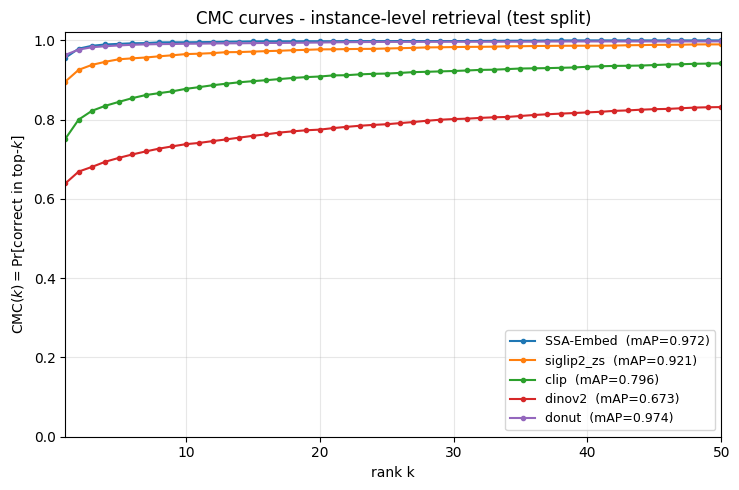


mAP + CMC summary (instance-level, test split):


,model,mAP,CMC@1,CMC@5,CMC@10,CMC@20
0,SSA-Embed,0.971640,0.955681,0.990905,0.994873,0.997519
1,siglip2_zs,0.920858,0.895651,0.952042,0.965107,0.977013
2,clip,0.796052,0.751282,0.844551,0.877460,0.908550
3,dinov2,0.672558,0.638829,0.703324,0.737887,0.774599
4,donut,0.973732,0.963122,0.986936,0.991235,0.994212


In [46]:
CMC_MAX_K = min(faiss_test.ntotal, 50)

cmc_data: Dict[str, np.ndarray] = {}
map_scores: Dict[str, float] = {}
for mname, qe, qs, ql, gi in MODELS_TO_COMPARE:
    cmc_data[mname]  = compute_cmc(qe, qs, gi, max_k=CMC_MAX_K)
    map_scores[mname] = instance_metrics(qe, qs, gi)['mAP']

fig, ax = plt.subplots(figsize=(7.5, 5))
COLORS_CMC = {'SSA-Embed': 'C0',
              'siglip2_zs': 'C1', 'clip': 'C2', 'dinov2': 'C3', 'donut': 'C4'}
for mname, curve in cmc_data.items():
    ax.plot(np.arange(1, len(curve) + 1), curve,
            marker='o', markersize=3,
            color=COLORS_CMC.get(mname, 'k'),
            label=f'{mname}  (mAP={map_scores[mname]:.3f})')
ax.set_xlabel('rank k')
ax.set_ylabel(r'CMC$(k) = \Pr[\mathrm{correct\ in\ top}\text{-}k]$')
ax.set_title('CMC curves - instance-level retrieval (test split)')
ax.set_xlim(1, CMC_MAX_K)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cmc_curves.png', dpi=140, bbox_inches='tight')
plt.show()

cmc_df = pd.DataFrame(
    {m: cmc_data[m] for m in cmc_data},
    index=pd.Index(np.arange(1, CMC_MAX_K + 1), name='rank_k'),
)
cmc_df.to_csv(OUT_DIR / 'cmc_curves.csv')

map_df = pd.DataFrame(
    [{'model': m, 'mAP': map_scores[m],
      'CMC@1': float(cmc_data[m][0]),
      'CMC@5': float(cmc_data[m][min(4, len(cmc_data[m]) - 1)]),
      'CMC@10': float(cmc_data[m][min(9, len(cmc_data[m]) - 1)]),
      'CMC@20': float(cmc_data[m][min(19, len(cmc_data[m]) - 1)])}
     for m in cmc_data]
)
map_df.to_csv(OUT_DIR / 'map_cmc_summary.csv', index=False)
print('\nmAP + CMC summary (instance-level, test split):')
display(map_df)


## 13b. Component ablation — isolate the contribution of each loss term

Six variants trained under the **same seed, same optimizer, same train/val loaders, same epoch count** as the main SSA-Embed run. Only the loss mix differs. All variants are evaluated on the same held-out test split with the same instance-level query set (`instance_qs`).

| variant                    | InfoNCE | distill | matra head | conj head | baseline head |
|----------------------------|:-:|:-:|:-:|:-:|:-:|
| `infonce_only`             | Y |   |   |   |   |
| `infonce_distill`          | Y | Y |   |   |   |
| `infonce_distill_matra`    | Y | Y | Y |   |   |
| `infonce_distill_conj`     | Y | Y |   | Y |   |
| `infonce_distill_baseline` | Y | Y |   |   | Y |
| `all`                      | Y | Y | Y | Y | Y |

The `all` row reuses `ssa_embed_v2.pt` (same recipe, same seed) so we don't retrain it. Per-variant training is resumable (only the latest `ablation/<name>_epoch_*.pt` is kept during training and it is pruned after `mark_done`); per-variant eval is cached (`ablation/<name>_eval.json`).


In [47]:
ABL_DIR = OUT_DIR / 'ablation'
ABL_DIR.mkdir(exist_ok=True)

ABL_EPOCHS = V2_EPOCHS

ABLATION_VARIANTS = [
    ('infonce_only',             dict(distill=False, matra=False, conj=False, baseline=False)),
    ('infonce_distill',          dict(distill=True,  matra=False, conj=False, baseline=False)),
    ('infonce_distill_matra',    dict(distill=True,  matra=True,  conj=False, baseline=False)),
    ('infonce_distill_conj',     dict(distill=True,  matra=False, conj=True,  baseline=False)),
    ('infonce_distill_baseline', dict(distill=True,  matra=False, conj=False, baseline=True)),
    ('all',                      dict(distill=True,  matra=True,  conj=True,  baseline=True)),
]
ABLATION_CFG = dict(ABLATION_VARIANTS)

def _abl_loss(batch, mdl, teach, cfg):
    x1 = batch['image'].to(DEVICE, non_blocking=True)
    x2 = batch['view'].to(DEVICE, non_blocking=True)
    need_dense = cfg['distill'] or cfg['matra'] or cfg['conj'] or cfg['baseline']
    if need_dense:
        emb1, aux = mdl(x1, return_dense=True)
    else:
        emb1 = mdl(x1); aux = None
    emb2 = mdl(x2)
    ins = instance_infonce(emb1, emb2, tau=V2_TAU)
    total = ins
    parts = {'ins': ins.detach()}
    if cfg['distill']:
        pooled1 = aux['tokens'].mean(dim=1)
        with torch.no_grad():
            t_out = teach(pixel_values=x1, return_dict=True)
            teacher_pooled = t_out.last_hidden_state.mean(dim=1)
        l_dis = distill_cos(pooled1, teacher_pooled)
        total = total + V2_LAMBDA_D * l_dis
        parts['dis'] = l_dis.detach()
    if cfg['matra']:
        l_m = bce_map(aux['matra'], batch['matra'].to(DEVICE))
        total = total + V2_LAMBDA_M * l_m
        parts['m'] = l_m.detach()
    if cfg['conj']:
        l_c = bce_map(aux['conj'], batch['conj'].to(DEVICE))
        total = total + V2_LAMBDA_C * l_c
        parts['c'] = l_c.detach()
    if cfg['baseline']:
        l_b = mse_map(aux['baseline'], batch['baseline'].to(DEVICE))
        total = total + V2_LAMBDA_B * l_b
        parts['b'] = l_b.detach()
    parts['total'] = total.detach()
    return total, parts

def _abl_reseed():
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    torch.cuda.manual_seed_all(SEED)

def _train_variant(name: str, cfg: dict = None) -> Path:
    if cfg is None:
        cfg = ABLATION_CFG[name]
    best_path = ABL_DIR / f'{name}_best.pt'
    done_key = f'ablation_{name}'

    if name == 'all' and V2_FINAL.exists():
        if not best_path.exists():
            shutil.copy2(V2_FINAL, best_path)
        mark_done(done_key, {'reused_from': str(V2_FINAL), 'path': str(best_path)})
        return best_path

    if is_done(done_key) and best_path.exists():
        return best_path

    _abl_reseed()
    fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
    mdl = SSAEmbed(fresh_vision, HIDDEN).to(DEVICE)
    for p in mdl.vision.parameters(): p.requires_grad = False
    for blk in mdl.vision.encoder.layers[-2:]:
        for p in blk.parameters(): p.requires_grad = True

    teach = None
    if cfg['distill']:
        teach = AutoModel.from_pretrained(SIGLIP_ID).vision_model.to(DEVICE).eval()
        for p in teach.parameters(): p.requires_grad = False

    opt = torch.optim.AdamW([p for p in mdl.parameters() if p.requires_grad],
                             lr=V2_LR, weight_decay=V2_WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=ABL_EPOCHS * max(1, len(v2_train_loader)))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_val = float('inf')
    start_epoch = 0
    ep_ckpts = sorted(ABL_DIR.glob(f'{name}_epoch_*.pt'),
                      key=lambda p: int(p.stem.split('_')[-1]))
    if ep_ckpts:
        st = torch.load(ep_ckpts[-1], map_location=DEVICE)
        mdl.load_state_dict(st['model'])
        opt.load_state_dict(st['opt'])
        try:
            sched.load_state_dict(st['sched'])
            scaler.load_state_dict(st['scaler'])
        except Exception as e:
            print(f'  [{name}] scheduler/scaler state skipped:', e)
        start_epoch = int(st['epoch'])
        best_val = float(st.get('best_val', best_val))
        print(f'  [{name}] resuming after epoch {start_epoch} (best_val={best_val:.4f})')

    for epoch in range(start_epoch, ABL_EPOCHS):
        mdl.train()
        pbar = tqdm(v2_train_loader, desc=f'{name} ep{epoch+1}/{ABL_EPOCHS}')
        for batch in pbar:
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                loss, parts = _abl_loss(batch, mdl, teach, cfg)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()
            pbar.set_postfix(ins=f'{parts["ins"].item():.3f}')

        mdl.eval()
        val_losses = []
        with torch.no_grad():
            for batch in v2_val_loader:
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                    _, parts = _abl_loss(batch, mdl, teach, cfg)
                val_losses.append(float(parts['total'].item()))
        vloss = float(np.mean(val_losses)) if val_losses else float('nan')
        print(f'  [{name}] epoch {epoch+1}: val_loss={vloss:.4f}')

        epoch_ckpt = ABL_DIR / f'{name}_epoch_{epoch+1}.pt'
        _atomic_torch_save({'model': mdl.state_dict(), 'opt': opt.state_dict(),
                            'sched': sched.state_dict(), 'scaler': scaler.state_dict(),
                            'epoch': epoch + 1, 'best_val': best_val},
                           epoch_ckpt)
        _prune_epoch_ckpts(ABL_DIR, f'{name}_epoch_*.pt', keep=epoch_ckpt)

        if vloss < best_val:
            best_val = vloss
            _atomic_torch_save(mdl.state_dict(), best_path)
            print(f'  -> [{name}] new best val_loss={best_val:.4f}')

    if teach is not None:
        del teach
    del mdl; torch.cuda.empty_cache()
    _cleanup_epoch_ckpts(ABL_DIR, f'{name}_epoch_*.pt')
    mark_done(done_key, {'best_val': best_val, 'path': str(best_path),
                         'epochs': ABL_EPOCHS, 'cfg': cfg})
    return best_path


In [48]:
print('=== ablation variant: infonce_only ===')
_train_variant('infonce_only')


=== ablation variant: infonce_only ===


PosixPath('/kaggle/working/bendir_out/ablation/infonce_only_best.pt')

In [49]:
# _snapshot('infonce_only')

In [50]:
print('=== ablation variant: infonce_distill ===')
_train_variant('infonce_distill')


=== ablation variant: infonce_distill ===


PosixPath('/kaggle/working/bendir_out/ablation/infonce_distill_best.pt')

In [51]:
# _snapshot('infonce_distill')

In [53]:
print('=== ablation variant: infonce_distill_matra ===')
_train_variant('infonce_distill_matra')


=== ablation variant: infonce_distill_matra ===


PosixPath('/kaggle/working/bendir_out/ablation/infonce_distill_matra_best.pt')

In [54]:
# _snapshot('infonce_distill_matra')

In [55]:
print('=== ablation variant: infonce_distill_conj ===')
_train_variant('infonce_distill_conj')


=== ablation variant: infonce_distill_conj ===


PosixPath('/kaggle/working/bendir_out/ablation/infonce_distill_conj_best.pt')

In [56]:
# _snapshot('infonce_distill_conj')

In [57]:
print('=== ablation variant: infonce_distill_baseline ===')
_train_variant('infonce_distill_baseline')


=== ablation variant: infonce_distill_baseline ===


PosixPath('/kaggle/working/bendir_out/ablation/infonce_distill_baseline_best.pt')

In [58]:
# _snapshot('infonce_distill_baseline')

In [59]:
print('=== ablation variant: all ===')
_train_variant('all')


=== ablation variant: all ===


PosixPath('/kaggle/working/bendir_out/ablation/all_best.pt')

In [60]:
def _eval_variant(name: str, weights_path: Path) -> dict:
    cache = ABL_DIR / f'{name}_eval.json'
    if cache.exists():
        return json.loads(cache.read_text())

    fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
    mdl = SSAEmbed(fresh_vision, HIDDEN).to(DEVICE)
    mdl.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    mdl.eval()

    g_emb, _, _ = embed_dataset(mdl, test_ds)
    g_emb = l2_normalize(g_emb)
    g_idx = build_faiss(g_emb)

    qe, qs, _ = embed_instance_queries(mdl, instance_qs)
    m = instance_metrics(qe, qs, g_idx)

    del mdl; torch.cuda.empty_cache()
    result = {'instance': m}
    cache.write_text(json.dumps(result))
    return result

ablation_rows = []
for _name, _cfg in ABLATION_VARIANTS:
    _weights = ABL_DIR / f'{_name}_best.pt'
    if not _weights.exists():
        print(f'skip {_name}: no weights')
        continue
    r = _eval_variant(_name, _weights)
    row = {'variant': _name,
           **{k: r['instance'][k] for k in ('R@1', 'R@5', 'R@10', 'MRR')}}
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(OUT_DIR / 'ablation_table.csv', index=False)
print('\nComponent ablation (higher = better; same test set, same seed protocol):')
display(ablation_df)



Component ablation (higher = better; same test set, same seed protocol):


,variant,R@1,R@5,R@10,MRR
0,infonce_only,0.868034,0.946420,0.964280,0.903707
1,infonce_distill,0.955019,0.991401,0.995535,0.970249
2,infonce_distill_matra,0.965437,0.992558,0.995204,0.977104
3,infonce_distill_conj,0.962130,0.990905,0.996693,0.975159
4,infonce_distill_baseline,0.950719,0.989582,0.993716,0.967843
5,all,0.955681,0.990905,0.994873,0.971641


In [61]:
# if len(ablation_rows) >= 5 and not is_done('snapshot_ablation'):
#     _snapshot('ablation')


### 13b. Ablation x degradation @ severity 3 — which head buys robustness?

Table 8 (`ablation_table.csv`) shows which loss term drives *clean* R@1.
This section extends that ablation to the **six-way degradation sweep at
severity 3** (the same operating point the paper's robustness table uses) so
we can see *which auxiliary head contributes to the robustness gap* claimed in
Sec. 5.4 / 5.5.

Design (kept cheap — no wasted work):

1. **`all` variant reuses the existing SSA-Embed severity-3 numbers**
   (`OUT_DIR/degradation_results.csv`), because `all` and the main model share
   weights. No re-embedding needed for that row.
2. For the other 5 variants, load `ABL_DIR/{variant}_best.pt`, build that
   variant's own gallery + FAISS index over `test_ds`, and evaluate **only at
   severity 3** across the six degradations (no severity 1 / 2).
3. Cache to `ABL_DIR/degradation_{variant}_sev3.csv`, resumable per degradation
   (a Kaggle timeout only loses the current degradation, not the whole variant).
4. Aggregate into a compact per-variant x per-degradation table and a
   delta-vs-`+distill` head-attribution view.

Outputs

- `ablation_degradation_severity3.csv` — per-variant severity-3 R@1 for
  {blur, jpeg, noise, downres, illum, skew} plus `hard_avg` = mean of the three
  genuinely-hard axes (noise / illum / skew).
- `ablation_degradation_head_attribution.csv` — pp change on each degradation
  vs `+distill` alone, so we can point at exactly which head (`matra`, `conj`,
  `baseline`, or `all`) buys which slice of robustness.


In [62]:
ABL_DEG_SEVERITY = 3

@torch.no_grad()
def _deg_sweep_ablation(variant_name: str, weights_path: Path) -> Path:
    """Severity-3-only degradation sweep for one ablation variant.

    - Reuses the existing SSA-Embed severity-3 numbers (`DEG_CSV`) for the
      `all` variant, since `all` shares weights with the main model.
    - Only computes severity 3 (not 1 / 2) for the other variants.
    - Resumable per degradation via a per-variant CSV.
    """
    csv_path = ABL_DIR / f'degradation_{variant_name}_sev3.csv'
    done_key = f'degradation_ablation_sev3_{variant_name}'

    if variant_name == 'all' and DEG_CSV.exists():
        main = pd.read_csv(DEG_CSV)
        sub = main[main['severity'] == ABL_DEG_SEVERITY].copy()
        if len(sub) == len(DEGRADATIONS):
            sub.to_csv(csv_path, index=False)
            mark_done(done_key, {'reused_from': str(DEG_CSV)})
            print(f'{variant_name}: reused SSA-Embed severity-3 from {DEG_CSV.name}')
            return csv_path

    if is_done(done_key) and csv_path.exists():
        print(f'{variant_name}: already complete -> {csv_path.name}')
        return csv_path

    if not weights_path.exists():
        print(f'{variant_name}: no weights at {weights_path}, skipping')
        return csv_path

    fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
    mdl = SSAEmbed(fresh_vision, HIDDEN).to(DEVICE)
    mdl.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    mdl.eval()

    g_emb, g_lab, _ = embed_dataset(mdl, test_ds)
    g_emb = l2_normalize(g_emb)
    g_idx = build_faiss(g_emb)

    base = list_split('test')
    src_idx_np = np.arange(len(base))

    done_rows = set()
    if csv_path.exists():
        _prev = pd.read_csv(csv_path)
        done_rows = set(_prev['degradation'].tolist())

    pbar = tqdm(total=len(DEGRADATIONS), desc=f'abl:{variant_name} sev{ABL_DEG_SEVERITY}')
    for deg_name in DEGRADATIONS:
        pbar.update(1)
        if deg_name in done_rows:
            continue
        ds = DegradedDataset(base, deg_name, ABL_DEG_SEVERITY)
        q_emb_d, q_lab_d, _ = embed_dataset(mdl, ds)
        q_emb_d = l2_normalize(q_emb_d)
        topk = min(g_idx.ntotal, 100)
        I = faiss_search(g_idx, q_emb_d, topk)
        match_self = (I == src_idx_np[:, None])
        match_cat  = (g_lab[I] == q_lab_d[:, None])
        row = {'degradation': deg_name, 'severity': ABL_DEG_SEVERITY}
        for k in (1, 5, 10):
            row[f'self_R@{k}'] = float(match_self[:, :k].any(1).mean())
            row[f'cat_R@{k}']  = float(match_cat[:, :k].any(1).mean())
        pd.DataFrame([row]).to_csv(csv_path, mode='a',
                                   header=not csv_path.exists(), index=False)
    pbar.close()

    del mdl; torch.cuda.empty_cache()
    mark_done(done_key)
    return csv_path


In [63]:
for _name, _cfg in ABLATION_VARIANTS:
    _w = ABL_DIR / f'{_name}_best.pt'
    print(f'\n=== degradation sweep :: {_name} ===')
    _deg_sweep_ablation(_name, _w)



=== degradation sweep :: infonce_only ===


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

embed:   0%|          | 0/378 [00:00<?, ?it/s]

abl:infonce_only sev3:   0%|          | 0/6 [00:00<?, ?it/s]

embed:   0%|          | 0/378 [00:00<?, ?it/s]

...

embed:   0%|          | 0/378 [00:00<?, ?it/s]

embed:   0%|          | 0/378 [00:00<?, ?it/s]

embed:   0%|          | 0/378 [00:00<?, ?it/s]

embed:   0%|          | 0/378 [00:00<?, ?it/s]


=== degradation sweep :: all ===
all: reused SSA-Embed severity-3 from degradation_results.csv


In [64]:
ablation_deg_rows = []
for _name, _cfg in ABLATION_VARIANTS:
    _csv = ABL_DIR / f'degradation_{_name}_sev3.csv'
    if not _csv.exists():
        print(f'skip {_name}: no sev3 csv yet')
        continue
    _df = pd.read_csv(_csv)
    _df = _df[_df['severity'] == ABL_DEG_SEVERITY]
    row = {'variant': _name}
    for _deg in DEGRADATIONS:
        sub = _df[_df['degradation'] == _deg]
        row[_deg] = float(sub['self_R@1'].iloc[0]) if len(sub) else float('nan')
    _hard_vals = [row[d] for d in ('noise', 'illum', 'skew')
                  if d in row and not np.isnan(row[d])]
    row['hard_avg'] = float(np.mean(_hard_vals)) if _hard_vals else float('nan')
    ablation_deg_rows.append(row)

ablation_deg = pd.DataFrame(ablation_deg_rows)
ablation_deg.to_csv(OUT_DIR / 'ablation_degradation_severity3.csv', index=False)
print(f'Ablation x degradation - instance R@1 at severity {ABL_DEG_SEVERITY} '
      f'(higher = better):')
display(ablation_deg)

# Head attribution: pp change on each degradation vs the +distill baseline.
_num_cols = list(DEGRADATIONS) + ['hard_avg']
if 'infonce_distill' in ablation_deg['variant'].values and len(ablation_deg):
    _base = ablation_deg.set_index('variant').loc['infonce_distill', _num_cols]
    _delta = (ablation_deg.set_index('variant')[_num_cols].sub(_base) * 100).round(2)
    _delta = _delta.drop(index=['infonce_only', 'infonce_distill'], errors='ignore')
    _delta.to_csv(OUT_DIR / 'ablation_degradation_head_attribution.csv')
    print(f'\nHead attribution vs +distill baseline '
          f'(delta pp on instance R@1, severity {ABL_DEG_SEVERITY}):')
    display(_delta)


Ablation x degradation - instance R@1 at severity 3 (higher = better):


,variant,blur,jpeg,noise,downres,illum,skew,hard_avg
0,infonce_only,0.994708,0.998512,0.795766,0.997685,0.887713,0.711593,0.798357
1,infonce_distill,0.997685,0.998512,0.894328,0.998677,0.944435,0.794774,0.877846
2,infonce_distill_matra,0.997850,0.998512,0.905573,0.998346,0.945593,0.780718,0.877295
3,infonce_distill_conj,0.998181,0.998512,0.895320,0.998512,0.944931,0.804035,0.881429
4,infonce_distill_baseline,0.997685,0.998346,0.895981,0.998512,0.944435,0.808169,0.882862
5,all,0.997850,0.998512,0.924756,0.998512,0.944601,0.781379,0.883579



Head attribution vs +distill baseline (delta pp on instance R@1, severity 3):


,blur,jpeg,noise,downres,illum,skew,hard_avg
variant,,,,,,,
infonce_distill_matra,0.02,0.00,1.12,-0.03,0.12,-1.41,-0.06
infonce_distill_conj,0.05,0.00,0.10,-0.02,0.05,0.93,0.36
infonce_distill_baseline,0.00,-0.02,0.17,-0.02,0.00,1.34,0.50
all,0.02,0.00,3.04,-0.02,0.02,-1.34,0.57


In [65]:
_snapshot('abaltion_degradation_sweep')

[snapshot:abaltion_degradation_sweep] staged 75 files, 4.47 GB (limit 10 GB / file)
[snapshot:abaltion_degradation_sweep] $ kaggle datasets version -p /kaggle/working/_snapshot_stage -m snapshot:abaltion_degradation_sweep (75 files, 4.47 GB) -r zip --dir-mode zip
[snapshot:abaltion_degradation_sweep] stdout:
Starting upload for file ablation_degradation_severity3.csv
Upload successful: ablation_degradation_severity3.csv (945B)
Starting upload for file ssa_embed.pt
Upload successful: ssa_embed.pt (360MB)
Starting upload for file baseline_clip.index
Upload successful: baseline_clip.index (18MB)
Starting upload for file baseline_dinov2_qemb.npy
Upload successful: baseline_dinov2_qemb.npy (18MB)
Starting upload for file multiseed_results.csv
Upload successful: multiseed_results.csv (342B)
Starting upload for file degradation_siglip2_zs.csv
Upload successful: degradation_siglip2_zs.csv (3KB)
Starting upload for file baseline_dinov2_emb.npy
Upload successful: baseline_dinov2_emb.npy (18MB)
S

True

### 13c. Multi-seed stability — SSA-Embed with 3 seeds

Re-runs the main SSA-Embed recipe with three different seeds and reports mean ± std on the instance-level self-retrieval metrics. Reviewers of retrieval papers routinely ask for this; a headline number without a std across seeds is treated as a single-run number.

- Seed `SEED` (=42) reuses `ssa_embed_v2.pt` bit-for-bit (same recipe, same weights). No retraining needed for that row.
- Seeds `SEED+1` and `SEED+2` train from scratch with the same optimizer / scheduler / loaders / epoch count as the main run. Only the RNG state and DataLoader shuffling differ.
- All three checkpoints and per-seed eval results are cached under `multiseed/`, so a Kaggle timeout is safe — re-running the cell resumes.

In [66]:
MULTISEED_DIR = OUT_DIR / 'multiseed'
MULTISEED_DIR.mkdir(exist_ok=True)

MULTISEED_SEEDS = [SEED, SEED + 1, SEED + 2]

def _train_multiseed(seed_val: int) -> Path:
    weights_path = MULTISEED_DIR / f'ssa_embed_seed{seed_val}.pt'
    done_key = f'multiseed_train_{seed_val}'

    if seed_val == SEED and V2_FINAL.exists():
        if not weights_path.exists():
            shutil.copy2(V2_FINAL, weights_path)
        mark_done(done_key, {'reused_from': str(V2_FINAL), 'path': str(weights_path)})
        return weights_path

    if is_done(done_key) and weights_path.exists():
        return weights_path

    torch.manual_seed(seed_val); np.random.seed(seed_val); random.seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

    tr_loader = DataLoader(v2_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, drop_last=True, pin_memory=True,
                           worker_init_fn=seed_worker,
                           generator=make_generator(seed_val))
    va_loader = DataLoader(v2_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, drop_last=False, pin_memory=True,
                           worker_init_fn=seed_worker,
                           generator=make_generator(seed_val))

    fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
    mdl = SSAEmbed(fresh_vision, HIDDEN).to(DEVICE)
    for p in mdl.vision.parameters(): p.requires_grad = False
    for blk in mdl.vision.encoder.layers[-2:]:
        for p in blk.parameters(): p.requires_grad = True

    teach = AutoModel.from_pretrained(SIGLIP_ID).vision_model.to(DEVICE).eval()
    for p in teach.parameters(): p.requires_grad = False

    opt = torch.optim.AdamW([p for p in mdl.parameters() if p.requires_grad],
                            lr=V2_LR, weight_decay=V2_WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=V2_EPOCHS * max(1, len(tr_loader)))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_val = float('inf')
    start_epoch = 0
    ep_ckpts = sorted(MULTISEED_DIR.glob(f'seed{seed_val}_epoch_*.pt'),
                      key=lambda p: int(p.stem.split('_')[-1]))
    if ep_ckpts:
        st = torch.load(ep_ckpts[-1], map_location=DEVICE)
        mdl.load_state_dict(st['model'])
        opt.load_state_dict(st['opt'])
        try:
            sched.load_state_dict(st['sched'])
            scaler.load_state_dict(st['scaler'])
        except Exception as e:
            print(f'  [seed{seed_val}] scheduler/scaler state skipped:', e)
        start_epoch = int(st['epoch'])
        best_val = float(st.get('best_val', best_val))
        print(f'  [seed{seed_val}] resuming after epoch {start_epoch} (best_val={best_val:.4f})')

    for epoch in range(start_epoch, V2_EPOCHS):
        mdl.train()
        pbar = tqdm(tr_loader, desc=f'seed{seed_val} ep{epoch+1}/{V2_EPOCHS}')
        for batch in pbar:
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                loss, parts = _v2_loss(batch, mdl, teach)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()
            pbar.set_postfix(ins=f'{parts["ins"].item():.3f}')

        v = _v2_val_loss(mdl, teach, va_loader)
        print(f'  [seed{seed_val}] epoch {epoch+1}: val={v["total"]:.4f}')

        epoch_ckpt = MULTISEED_DIR / f'seed{seed_val}_epoch_{epoch+1}.pt'
        _atomic_torch_save({'model': mdl.state_dict(), 'opt': opt.state_dict(),
                            'sched': sched.state_dict(), 'scaler': scaler.state_dict(),
                            'epoch': epoch + 1, 'best_val': best_val},
                           epoch_ckpt)
        _prune_epoch_ckpts(MULTISEED_DIR, f'seed{seed_val}_epoch_*.pt', keep=epoch_ckpt)

        if v['total'] < best_val:
            best_val = float(v['total'])
            _atomic_torch_save(mdl.state_dict(), weights_path)
            print(f'  -> [seed{seed_val}] new best val_loss={best_val:.4f}')

    del teach, mdl; torch.cuda.empty_cache()
    _cleanup_epoch_ckpts(MULTISEED_DIR, f'seed{seed_val}_epoch_*.pt')
    mark_done(done_key, {'best_val': best_val, 'path': str(weights_path),
                         'epochs': V2_EPOCHS, 'seed': seed_val})
    return weights_path

def _eval_seed(weights_path: Path) -> Dict[str, float]:
    fresh_vision = AutoModel.from_pretrained(SIGLIP_ID).vision_model
    mdl = SSAEmbed(fresh_vision, HIDDEN).to(DEVICE)
    mdl.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    mdl.eval()

    g_emb, _, _ = embed_dataset(mdl, test_ds)
    g_emb = l2_normalize(g_emb)
    g_idx = build_faiss(g_emb)

    qe, qs, _ = embed_instance_queries(mdl, instance_qs)
    m = instance_metrics(qe, qs, g_idx)

    del mdl; torch.cuda.empty_cache()
    return m


In [67]:
print(f'=== training seed {SEED} ===')
_train_multiseed(SEED)


=== training seed 44 ===


PosixPath('/kaggle/working/bendir_out/multiseed/ssa_embed_seed44.pt')

In [68]:
print(f'=== training seed {SEED + 1} ===')
_train_multiseed(SEED + 1)


=== training seed 45 ===


PosixPath('/kaggle/working/bendir_out/multiseed/ssa_embed_seed45.pt')

In [69]:
print(f'=== training seed {SEED + 2} ===')
_train_multiseed(SEED + 2)


=== training seed 46 ===


PosixPath('/kaggle/working/bendir_out/multiseed/ssa_embed_seed46.pt')

### 13c.4 Aggregate mean +/- std across seeds


In [70]:
multiseed_rows = []
for _seed in MULTISEED_SEEDS:
    _cache = MULTISEED_DIR / f'seed{_seed}_eval.json'
    _w = MULTISEED_DIR / f'ssa_embed_seed{_seed}.pt'
    if not _cache.exists():
        if not _w.exists():
            print(f'seed {_seed}: no weights and no cache')
            continue
        m = _eval_seed(_w)
        _cache.write_text(json.dumps(m))
    else:
        m = json.loads(_cache.read_text())
    multiseed_rows.append({'seed': _seed, **m})

multiseed_df = pd.DataFrame(multiseed_rows)
_metric_cols = ['R@1', 'R@5', 'R@10', 'MRR', 'mAP']
_metric_cols = [c for c in _metric_cols if c in multiseed_df.columns]
mean_row = {'seed': 'mean', **{k: float(multiseed_df[k].mean()) for k in _metric_cols}}
std_row  = {'seed': 'std',  **{k: float(multiseed_df[k].std())  for k in _metric_cols}}
multiseed_summary = pd.DataFrame([mean_row, std_row])

multiseed_df.to_csv(OUT_DIR / 'multiseed_results.csv', index=False)
multiseed_summary.to_csv(OUT_DIR / 'multiseed_summary.csv', index=False)

print('Multi-seed SSA-Embed results (higher = better):')
display(multiseed_df)
print('\nMean +/- std across seeds:')
display(multiseed_summary)


Multi-seed SSA-Embed results (higher = better):


,seed,R@1,R@5,R@10,MRR,mAP,median_rank
0,44,0.955681,0.990905,0.994873,0.971641,0.971640,1.0
1,45,0.956507,0.990574,0.995370,0.971546,0.971545,1.0
2,46,0.958492,0.990078,0.995204,0.972938,0.972938,1.0



Mean +/- std across seeds:


,seed,R@1,R@5,R@10,MRR,mAP
0,mean,0.956893,0.990519,0.995149,0.972042,0.972041
1,std,0.001445,0.000416,0.000253,0.000778,0.000779


In [71]:
# if len(multiseed_rows) >= 3 and not is_done('snapshot_multiseed'):
#     _snapshot('multiseed')


## 14. Save final results and list all uploadable artifacts

In [72]:
summary = {
    'dataset_root': str(DATA_ROOT),
    'categories': CATEGORIES,
    'split_counts': counts,
    'protocol': {
        'training':   'train split only (val used for model selection, test held out)',
        'retrieval':  'instance-level: query = augmented view, hit = same source image',
        'query_augmentation': 'rotation +/-3deg, GaussianBlur k=3, brightness/contrast jitter, JPEG Q=70',
    },
    'ssa_full_page':          ssa_full_page,
    'ssa_per_genre':          ssa_per_genre,
    'baselines_full_page':    baseline_full.to_dict(orient='records'),
    'per_genre_comparison':   per_genre_comp.to_dict(orient='records'),
    'degradation_summary_s3': deg_summary.to_dict(orient='records'),
    'ablation':               ablation_df.to_dict(orient='records') if 'ablation_df' in globals() else None,
    'multiseed_results':      multiseed_df.to_dict(orient='records') if 'multiseed_df' in globals() else None,
    'multiseed_summary':      multiseed_summary.to_dict(orient='records') if 'multiseed_summary' in globals() else None,
    'map_cmc_summary':        map_df.to_dict(orient='records') if 'map_df' in globals() else None,
    'cmc_max_k':              int(CMC_MAX_K) if 'CMC_MAX_K' in globals() else None,
    'state':                  load_state(),
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, default=float))
print('wrote', OUT_DIR / 'summary.json')

print('\nArtifacts in', OUT_DIR)
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f'  {size_mb:8.2f} MB  {p.relative_to(OUT_DIR)}')


wrote /kaggle/working/bendir_out/summary.json

Artifacts in /kaggle/working/bendir_out
    360.41 MB  ablation/all_best.pt
      0.00 MB  ablation/all_eval.json
    360.41 MB  ablation/infonce_distill_baseline_best.pt
      0.00 MB  ablation/infonce_distill_baseline_eval.json
    360.41 MB  ablation/infonce_distill_best.pt
    360.41 MB  ablation/infonce_distill_conj_best.pt
      0.00 MB  ablation/infonce_distill_conj_eval.json
      0.00 MB  ablation/infonce_distill_eval.json
    360.41 MB  ablation/infonce_distill_matra_best.pt
      0.00 MB  ablation/infonce_distill_matra_eval.json
    360.41 MB  ablation/infonce_only_best.pt
      0.00 MB  ablation/infonce_only_eval.json
      0.00 MB  ablation_table.csv
     17.72 MB  baseline_clip.index
     17.72 MB  baseline_clip_emb.npy
     17.72 MB  baseline_clip_qemb.npy
      0.05 MB  baseline_clip_qlab.npy
      0.05 MB  baseline_clip_qsrc.npy
     17.72 MB  baseline_dinov2.index
     17.72 MB  baseline_dinov2_emb.npy
     17.72 MB  base

## 15. Final snapshot to a Kaggle Dataset

Intermediate snapshots have already fired after **V2 training / baselines / degradation sweep / ablation / multi-seed**. This cell pushes one final version containing `summary.json` and any remaining artifacts. Every snapshot is a new version of the same dataset, so nothing is lost.

**One-time setup on Kaggle** (skip if already configured — snapshots earlier in the notebook would have printed *no kaggle credentials; skipping*):

1. Get an API token at https://www.kaggle.com/settings/account -> *Create New Token* (downloads `kaggle.json` with your `username` and `key`).
2. In this notebook, open **Add-ons -> Secrets** and add two secrets:
   - `KAGGLE_USERNAME` - your Kaggle username
   - `KAGGLE_KEY` - the `key` value from `kaggle.json`
3. Make sure the notebook has **Internet: On** in the Settings panel.

**Restore in a new session:** if the previous session snapshotted, open **Add data → Your Datasets → `bendir-ssa-embed-artifacts`**. The state-helpers cell auto-detects the attached dataset and mirrors it into `bendir_out/` before any stage runs, so every completed stage no-ops via `is_done(...)`.

Set `SNAPSHOT_PUBLIC = True` in the state-helpers cell if you want the dataset published for the paper.


In [74]:
# _snapshot('final')
